# CV Mechanism Classification — ResNet1D vs. Traditional ML Baselines

**Project:** CMU 11-785 Intro to Deep Learning (Spring 2026)  
**Paper:** Hoar et al. (2022) — *Electrochemical Mechanistic Analysis from Cyclic Voltammograms Based on Deep Learning*

**Goal:** Classify 5 electrochemical reaction mechanisms (E, EC, CE, ECE, DISP1) from simulated cyclic voltammograms using:
1. A 1D ResNet-18 (CNN approach from the paper)
2. Traditional ML baselines (Random Forest, Logistic Regression) on hand-crafted features

---

### Notebook Outline
1. **Setup & Imports**
2. **Data Generation** — Simulate CV dataset
3. **Data Exploration** — Visualise the signals and class distributions
4. **Feature Engineering** — Extract hand-crafted electrochemical features
5. **Baseline Models** — Random Forest & Logistic Regression
6. **CNN Training** — ResNet1D-18
7. **Model Comparison** — Side-by-side results

## 1. Setup & Imports

In [1]:
!python -m pip install --upgrade wandb

import sys, os
sys.path.insert(0, os.path.abspath(".."))

import logging
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

# Project imports
from src.data.cv_dataset import CVDataset, create_cv_dataloaders
from src.data.cv_features import extract_features_batch, feature_names
from src.models import get_model, list_models
from src.models.baseline_ml import BaselineClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")

# Plotting style
plt.rcParams.update({
    "figure.facecolor": "#FAFAFA",
    "axes.facecolor": "#FAFAFA",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "figure.dpi": 120,
})

# Colour palette — CE absent from the zip dataset
MECH_COLORS = {
    "DISP1": "#DD8452", "E": "#55A868",
    "EC": "#C44E52", "ECE": "#8172B3",
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Registered models: {list_models()}")

   ---------------------------------------- 0.0/25.0 MB ? eta -:--:--
   --- ------------------------------------ 2.1/25.0 MB 11.8 MB/s eta 0:00:02
   ---------- ----------------------------- 6.8/25.0 MB 17.5 MB/s eta 0:00:02
   ---------------------- ----------------- 14.2/25.0 MB 24.0 MB/s eta 0:00:01
   ------------------------------------- -- 23.3/25.0 MB 29.5 MB/s eta 0:00:01
   ---------------------------------------- 25.0/25.0 MB 27.7 MB/s  0:00:00
  Attempting uninstall: wandb
    Found existing installation: wandb 0.25.0
    Uninstalling wandb-0.25.0:
      Successfully uninstalled wandb-0.25.0
Device: cpu
Registered models: ['placeholder', 'resnet1d_18']


## 2. Load Dataset

Load the pre-simulated cyclic voltammogram dataset from `data/simulated/simulated_cvs.npz`.
Each sample contains CVs at 6 scan rates ([0.10, 0.16, 0.25, 0.40, 0.63, 1.00] V/s), with
1 channel per scan rate (full current trace) and 500 discretised potential points.
The dataset covers 4 mechanisms: **DISP1, E, EC, ECE** (3 000 samples each, 12 000 total).

In [2]:
DATA_DIR = "../data/simulated"

# Load pre-simulated dataset (physically accurate Butler-Volmer simulation)
data = np.load(f"{DATA_DIR}/simulated_cvs.npz")

# Derive class list and integer labels from the string labels in the file
labels_str = data["labels"]                               # (12000,) str
MECHANISMS = sorted(set(labels_str.tolist()))             # ['DISP1','E','EC','ECE']
MECHANISM_TO_IDX = {m: i for i, m in enumerate(MECHANISMS)}
labels = np.array([MECHANISM_TO_IDX[l] for l in labels_str], dtype=np.int64)

signals    = data["signals"]    # (12000, 6, 500)
scan_rates = data["scan_rates"] # (12000, 6)  — per-sample scan rate arrays
potential  = data["potentials"] # (500,)       — shared potential axis

print(f"Signals shape:    {signals.shape}  (samples, scan_rates, potential_points)")
print(f"Labels shape:     {labels.shape}")
print(f"Mechanisms:       {MECHANISMS}")
print(f"Class distribution: {dict(Counter(labels))}")
print(f"Scan rates (sample 0): {scan_rates[0]}")
print(f"Potential range:  [{potential.min():.3f}, {potential.max():.3f}] V")

Signals shape:    (12000, 6, 500)  (samples, scan_rates, potential_points)
Labels shape:     (12000,)
Mechanisms:       ['DISP1', 'E', 'EC', 'ECE']
Class distribution: {np.int64(1): 3000, np.int64(2): 3000, np.int64(3): 3000, np.int64(0): 3000}
Scan rates (sample 0): [0.1  0.16 0.25 0.4  0.63 1.  ]
Potential range:  [-0.380, 0.618] V


In [3]:
# ============================================================
# RUN CONTROL — edit before "Run All"
# ============================================================
SKIP_TRAINING = True

# Checkpoint to load when SKIP_TRAINING = True.
# None → auto-uses checkpoints/best_resnet1d.pt
RESUME_CHECKPOINT = None
# ============================================================

if SKIP_TRAINING:
    _disp = RESUME_CHECKPOINT or "checkpoints/best_resnet1d.pt"
    print(f"[RUN CONTROL] SKIP_TRAINING=True — will load: {_disp}")
    print("  Training cell + W&B init will be skipped.")
else:
    print("[RUN CONTROL] SKIP_TRAINING=False — full training run.")


[RUN CONTROL] SKIP_TRAINING=True — will load: checkpoints/best_resnet1d.pt
  Training cell + W&B init will be skipped.


## 3. Data Exploration

### 3.1 Class Distribution

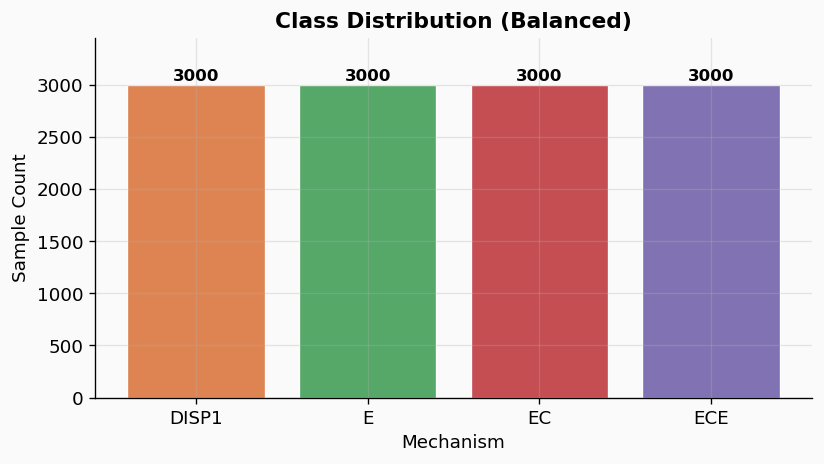

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))

counts = Counter(labels.tolist())   # integer-encoded labels defined in §2
classes = [MECHANISMS[i] for i in sorted(counts.keys())]
values  = [counts[i] for i in sorted(counts.keys())]
colors  = [MECH_COLORS[c] for c in classes]

bars = ax.bar(classes, values, color=colors, edgecolor="white", linewidth=0.8)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
            str(v), ha="center", va="bottom", fontweight="bold", fontsize=10)

ax.set_xlabel("Mechanism")
ax.set_ylabel("Sample Count")
ax.set_title("Class Distribution (Balanced)")
ax.set_ylim(0, max(values) * 1.15)
plt.tight_layout()
plt.show()

### 3.2 Example CVs per Mechanism

Each panel shows the forward (solid) and reverse (dashed) current vs. potential for a single sample at scan rate index 0 (slowest).

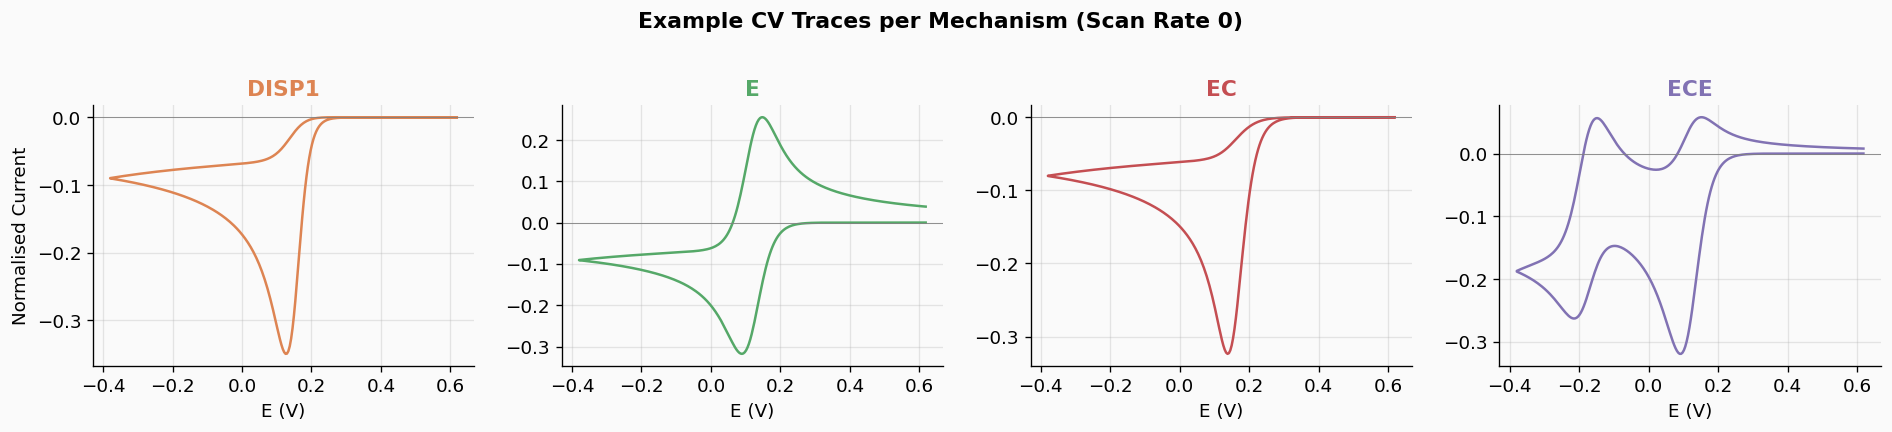

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=False)

for idx, mech in enumerate(MECHANISMS):
    ax = axes[idx]
    sample_idx = np.where(labels == idx)[0][0]
    trace = signals[sample_idx, 0, :]  # scan rate 0, full CV trace

    ax.plot(potential, trace, color=MECH_COLORS[mech], linewidth=1.5)
    ax.set_title(mech, color=MECH_COLORS[mech])
    ax.set_xlabel("E (V)")
    if idx == 0:
        ax.set_ylabel("Normalised Current")
    ax.axhline(0, color="grey", linewidth=0.5, linestyle="-")

fig.suptitle("Example CV Traces per Mechanism (Scan Rate 0)", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Scan Rate Dependence

A key diagnostic: how CV shape changes across scan rates for each mechanism. This is the primary signal the CNN learns from.

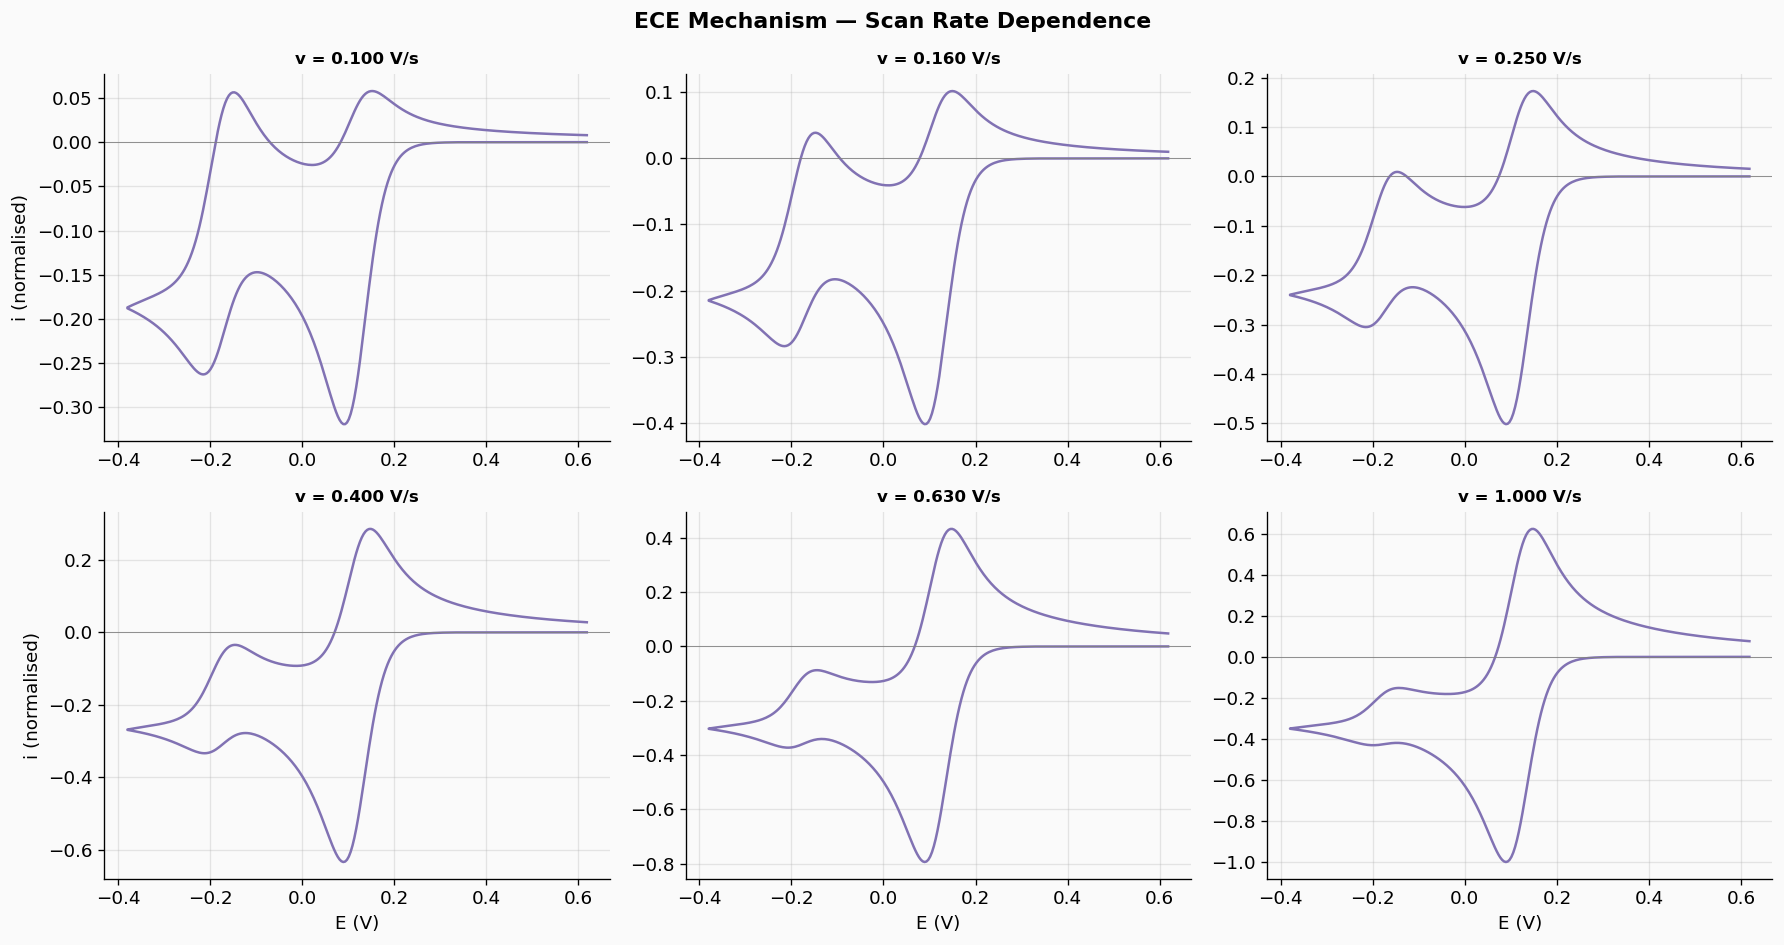

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Pick one mechanism (ECE — most interesting multi-peak structure)
mech_idx = MECHANISM_TO_IDX["ECE"]
sample_idx = np.where(labels == mech_idx)[0][0]
sr_values = scan_rates[sample_idx]  # (6,) scan rates for this sample

for sr_i in range(6):
    ax = axes[sr_i]
    trace = signals[sample_idx, sr_i, :]
    ax.plot(potential, trace, color=MECH_COLORS["ECE"], linewidth=1.5)
    ax.set_title(f"v = {sr_values[sr_i]:.3f} V/s", fontsize=10)
    ax.axhline(0, color="grey", linewidth=0.5)
    if sr_i >= 3:
        ax.set_xlabel("E (V)")
    if sr_i % 3 == 0:
        ax.set_ylabel("i (normalised)")

fig.suptitle("ECE Mechanism — Scan Rate Dependence", fontweight="bold")
plt.tight_layout()
plt.show()

### 3.4 Signal Variability Within a Class

Overlay multiple samples of the same mechanism to see intra-class variation due to random electrochemical parameters.

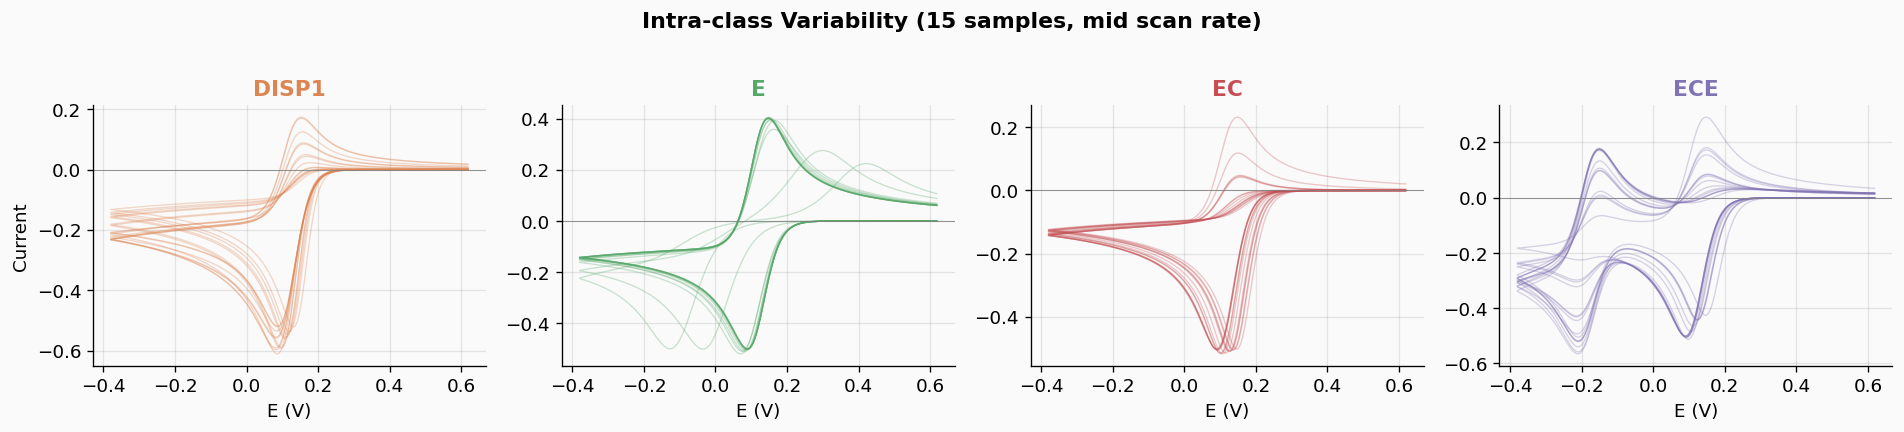

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=False)
N_OVERLAY = 15

for idx, mech in enumerate(MECHANISMS):
    ax = axes[idx]
    class_indices = np.where(labels == idx)[0][:N_OVERLAY]
    for si in class_indices:
        trace = signals[si, 2, :]  # scan rate index 2 (mid-range), full trace
        ax.plot(potential, trace, color=MECH_COLORS[mech], alpha=0.3, linewidth=0.8)
    ax.set_title(mech, color=MECH_COLORS[mech])
    ax.set_xlabel("E (V)")
    if idx == 0:
        ax.set_ylabel("Current")
    ax.axhline(0, color="grey", linewidth=0.5)

fig.suptitle(f"Intra-class Variability ({N_OVERLAY} samples, mid scan rate)",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3.5 Channel Heatmap

Visualise the full 18-channel input tensor (6 scan rates x 3 channels) for a single sample. This is exactly what the CNN "sees".

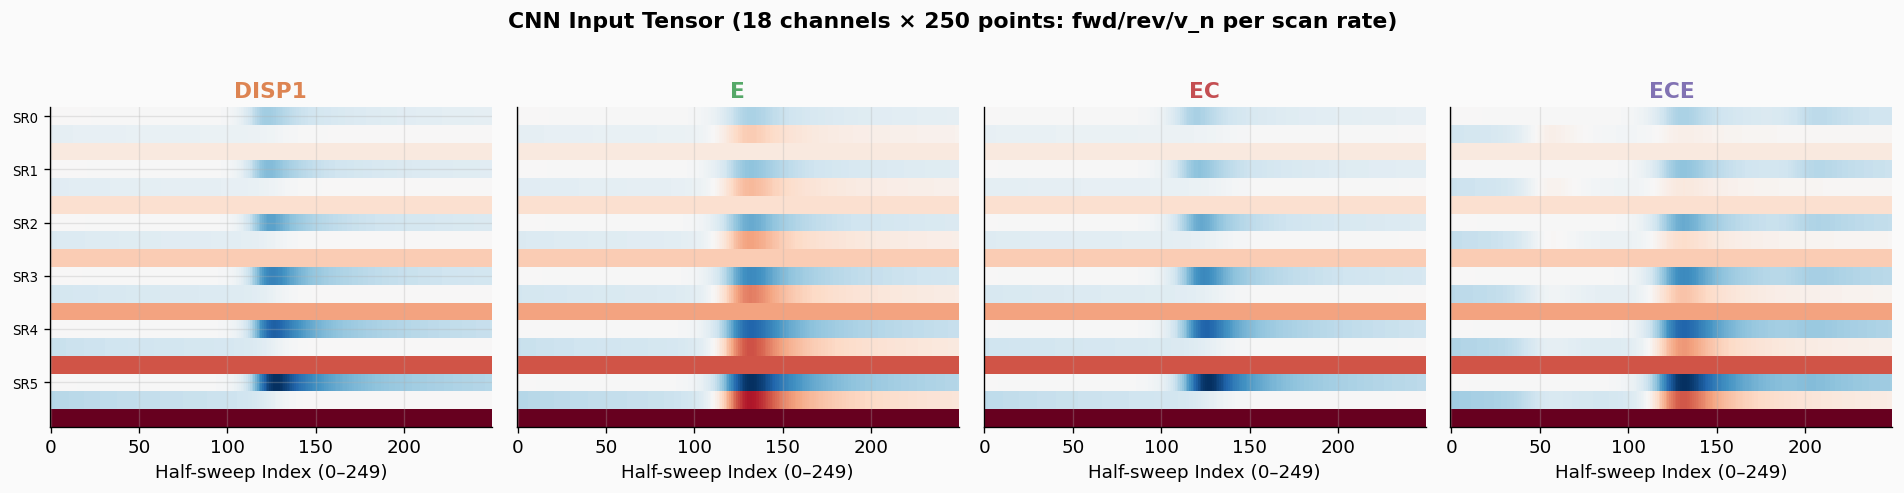

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

def reconstruct_tensor(raw_trace, sr_val):
    """Rebuild paper's 3-channel layout from a single (6, 500) raw trace.
    Returns (18, 250): [i_for, i_rev, v_n] × 6 scan rates."""
    n_sr, L = raw_trace.shape
    mid = L // 2
    out = np.empty((n_sr * 3, mid), dtype=np.float32)
    for i in range(n_sr):
        out[i * 3]     = raw_trace[i, :mid]   # i_for
        out[i * 3 + 1] = raw_trace[i, mid:]   # i_rev
        out[i * 3 + 2] = sr_val[i]            # v_n (constant)
    return out

for idx, mech in enumerate(MECHANISMS):
    ax = axes[idx]
    sample_idx = np.where(labels == idx)[0][0]
    tensor = reconstruct_tensor(signals[sample_idx], scan_rates[sample_idx])  # (18, 250)

    im = ax.imshow(tensor, aspect="auto", cmap="RdBu_r", interpolation="nearest")
    ax.set_title(mech, color=MECH_COLORS[mech])
    ax.set_xlabel("Half-sweep Index (0–249)")
    if idx == 0:
        ax.set_yticks(range(0, 18, 3))
        ax.set_yticklabels([f"SR{i}" for i in range(6)], fontsize=8)
    else:
        ax.set_yticks([])

fig.suptitle("CNN Input Tensor (18 channels × 250 points: fwd/rev/v_n per scan rate)",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4. Load Dataset & Extract Features

In [9]:
# Load via CVDataset — produces (18, 250) tensors in paper's 3-channel format
train_ds = CVDataset(DATA_DIR, split="train", noise_sigma=0.3, baseline_drift=0.05)
val_ds   = CVDataset(DATA_DIR, split="val")
test_ds  = CVDataset(DATA_DIR, split="test")

print(f"Train: {len(train_ds):>6d} samples")
print(f"Val:   {len(val_ds):>6d} samples")
print(f"Test:  {len(test_ds):>6d} samples")
print(f"CNN input shape per sample: {tuple(train_ds._signals.shape[1:])}")

# For baseline feature extraction, use the raw (6, 500) signals directly
# so cv_features.py can split them at the midpoint into fwd/rev halves.
X_train_raw = signals[train_ds._indices]   # (N_train, 6, 500)
X_val_raw   = signals[val_ds._indices]
X_test_raw  = signals[test_ds._indices]

y_train = train_ds._labels[train_ds._indices]
y_val   = val_ds._labels[val_ds._indices]
y_test  = test_ds._labels[test_ds._indices]

print(f"\nRaw signals for feature extraction: {X_train_raw.shape}")

INFO | CVDataset(train): 9600 samples, shape=(18, 250), noise=0.30, drift=0.05
INFO | CVDataset(val): 1200 samples, shape=(18, 250), noise=0.00, drift=0.00
INFO | CVDataset(test): 1200 samples, shape=(18, 250), noise=0.00, drift=0.00


Train:   9600 samples
Val:     1200 samples
Test:    1200 samples
CNN input shape per sample: (18, 250)

Raw signals for feature extraction: (9600, 6, 500)


In [10]:
# Extract hand-crafted features for baseline models (from raw 6×500 signals)
print("Extracting features...")
X_train_feat = extract_features_batch(X_train_raw)
X_val_feat   = extract_features_batch(X_val_raw)
X_test_feat  = extract_features_batch(X_test_raw)

print(f"Feature vector: {X_train_feat.shape[1]} dimensions")
print(f"\nFeature groups:")
print(f"  Per scan rate (×6): peak currents, positions, separation, ratio, width, areas")
print(f"  Global (×5): Randles-Sevcik slope, mean/std peak ratio & separation")

Extracting features...
Feature vector: 59 dimensions

Feature groups:
  Per scan rate (×6): peak currents, positions, separation, ratio, width, areas
  Global (×5): Randles-Sevcik slope, mean/std peak ratio & separation


### What the 59 features represent

For each of the **6 scan rates**, `cv_features.py` computes **9 per-SR features** by splitting the 500-point CV trace at the midpoint into a forward (anodic) and reverse (cathodic) half-sweep:

| Feature | Electrochemical meaning |
|---|---|
| `fwd_peak_current` | Height of the anodic (oxidation) peak — scales with √(scan rate) under diffusion control (Randles-Ševčík law) |
| `rev_peak_current` | Depth of the cathodic (reduction) peak — shrinks or vanishes if a chemical step consumes the product (**EC** signature) |
| `fwd_peak_pos` / `rev_peak_pos` | Potential at which each peak occurs — reversible reactions peak near E°; irreversible ones shift with scan rate |
| `peak_separation` | Distance between anodic and cathodic peak potentials — ≈59 mV/n for reversible **E**; grows with scan rate for quasi-reversible; very large for irreversible |
| `peak_current_ratio` | \|cathodic\| / anodic — ≈1.0 for reversible **E**; <1 if a following reaction destroys product (**EC**); >1 for **CE** |
| `half_peak_width` | Width of the anodic peak at half-height — broad peaks indicate slow electron-transfer kinetics |
| `fwd_area` / `rev_area` | Charge passed in each half-sweep — asymmetry between them reveals irreversibility |

Plus **5 global features** computed *across* all scan rates:

| Feature | What it captures |
|---|---|
| `randles_sevcik_slope` | Slope of peak current vs √(scan rate) — linear for diffusion control, deviates for **CE/ECE/DISP1** |
| `mean_peak_ratio` | How consistently reversible the reaction is across all scan rates |
| `std_peak_separation` | How much peak separation *changes* with scan rate — key discriminator for **DISP1 vs ECE** |
| `std_fwd_peak_current` | Variance of peak height across scan rates — diagnostic for **CE** (peak grows differently) |
| `mean_peak_separation` | Overall reversibility summary |

**Random Forest and Logistic Regression see only these 59 numbers.** They learn threshold rules like *"if `peak_current_ratio` < 0.5 at high scan rates AND `randles_sevcik_slope` is low → probably EC"*. They never see the raw waveform.

### 4.1 Feature Distributions

Examine a few key features coloured by mechanism class to understand separability.

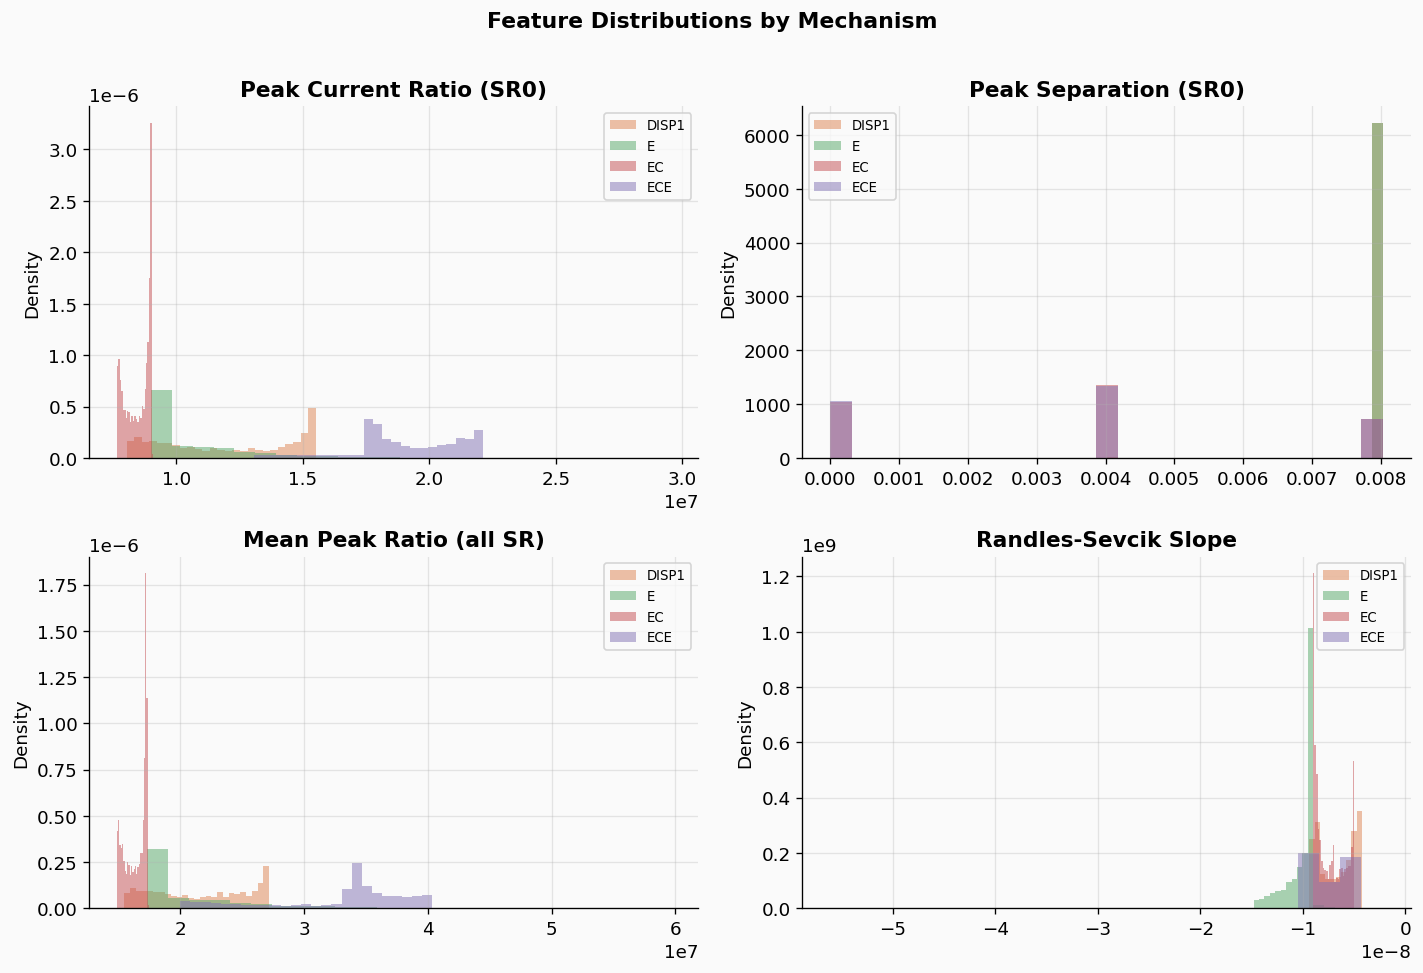

In [11]:
names = feature_names()
# Select informative features to visualise
show_features = [
    ("sr0_peak_current_ratio", "Peak Current Ratio (SR0)"),
    ("sr0_peak_separation", "Peak Separation (SR0)"),
    ("mean_peak_ratio", "Mean Peak Ratio (all SR)"),
    ("randles_sevcik_slope", "Randles-Sevcik Slope"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (feat_name, title) in zip(axes, show_features):
    feat_idx = names.index(feat_name)
    for mech_idx, mech in enumerate(MECHANISMS):
        mask = y_train == mech_idx
        ax.hist(X_train_feat[mask, feat_idx], bins=25, alpha=0.5,
                color=MECH_COLORS[mech], label=mech, density=True)
    ax.set_title(title)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

fig.suptitle("Feature Distributions by Mechanism", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---

## 5. Baseline Models — Traditional ML

### 5.1 Random Forest

In [12]:
rf_clf = BaselineClassifier(method="random_forest", params={"n_estimators": 200})
rf_clf.fit(X_train_feat, y_train)

rf_train_acc = rf_clf.score(X_train_feat, y_train)
rf_val_acc = rf_clf.score(X_val_feat, y_val)
rf_test_acc = rf_clf.score(X_test_feat, y_test)

print(f"Random Forest Results:")
print(f"  Train accuracy: {rf_train_acc:.4f}")
print(f"  Val accuracy:   {rf_val_acc:.4f}")
print(f"  Test accuracy:  {rf_test_acc:.4f}")

INFO | Fitting random_forest on 9600 samples with 59 features


Random Forest Results:
  Train accuracy: 1.0000
  Val accuracy:   1.0000
  Test accuracy:  1.0000


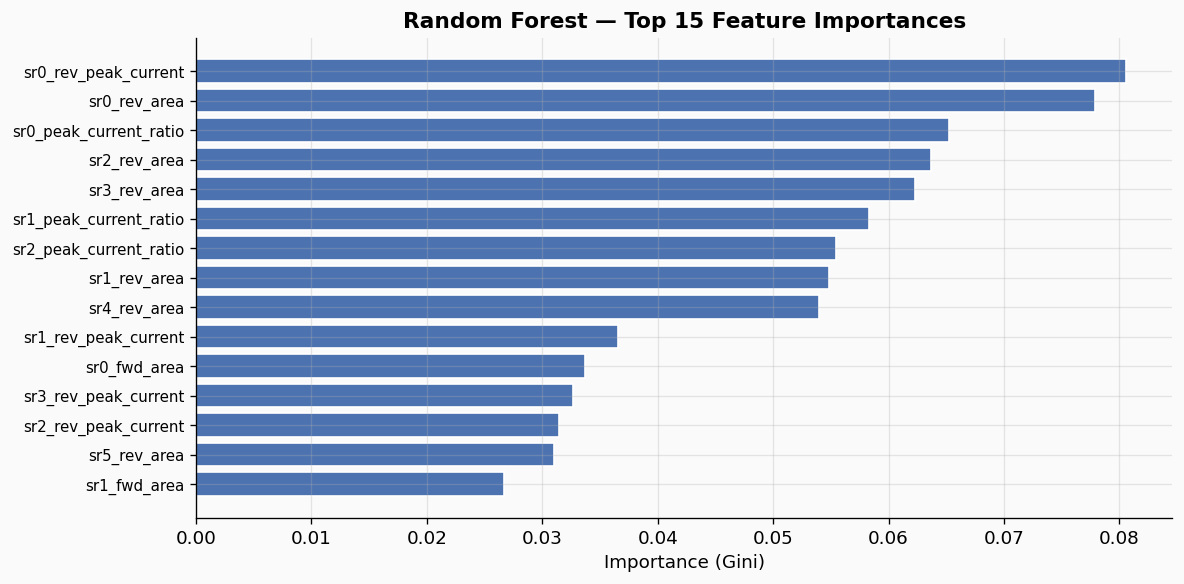

In [13]:
# Feature importance
importances = rf_clf.feature_importances()
feat_names = feature_names()
top_k = 15

top_idx = np.argsort(importances)[-top_k:][::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(top_k), importances[top_idx][::-1], color="#4C72B0", edgecolor="white")
ax.set_yticks(range(top_k))
ax.set_yticklabels([feat_names[i] for i in top_idx][::-1], fontsize=9)
ax.set_xlabel("Importance (Gini)")
ax.set_title(f"Random Forest — Top {top_k} Feature Importances")
plt.tight_layout()
plt.show()

### 5.2 Logistic Regression

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Logistic regression benefits from feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_val_scaled = scaler.transform(X_val_feat)
X_test_scaled = scaler.transform(X_test_feat)

# lr_clf = BaselineClassifier(method="logistic")
lr_clf = LogisticRegression()
lr_clf.fit(X_train_scaled, y_train)

lr_train_acc = lr_clf.score(X_train_scaled, y_train)
lr_val_acc = lr_clf.score(X_val_scaled, y_val)
lr_test_acc = lr_clf.score(X_test_scaled, y_test)

print(f"Logistic Regression Results:")
print(f"  Train accuracy: {lr_train_acc:.4f}")
print(f"  Val accuracy:   {lr_val_acc:.4f}")
print(f"  Test accuracy:  {lr_test_acc:.4f}")

Logistic Regression Results:
  Train accuracy: 0.9989
  Val accuracy:   0.9983
  Test accuracy:  1.0000


### 5.3 Baseline Confusion Matrices

C:\Users\zanet\AppData\Local\Temp\ipykernel_118848\2327814160.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


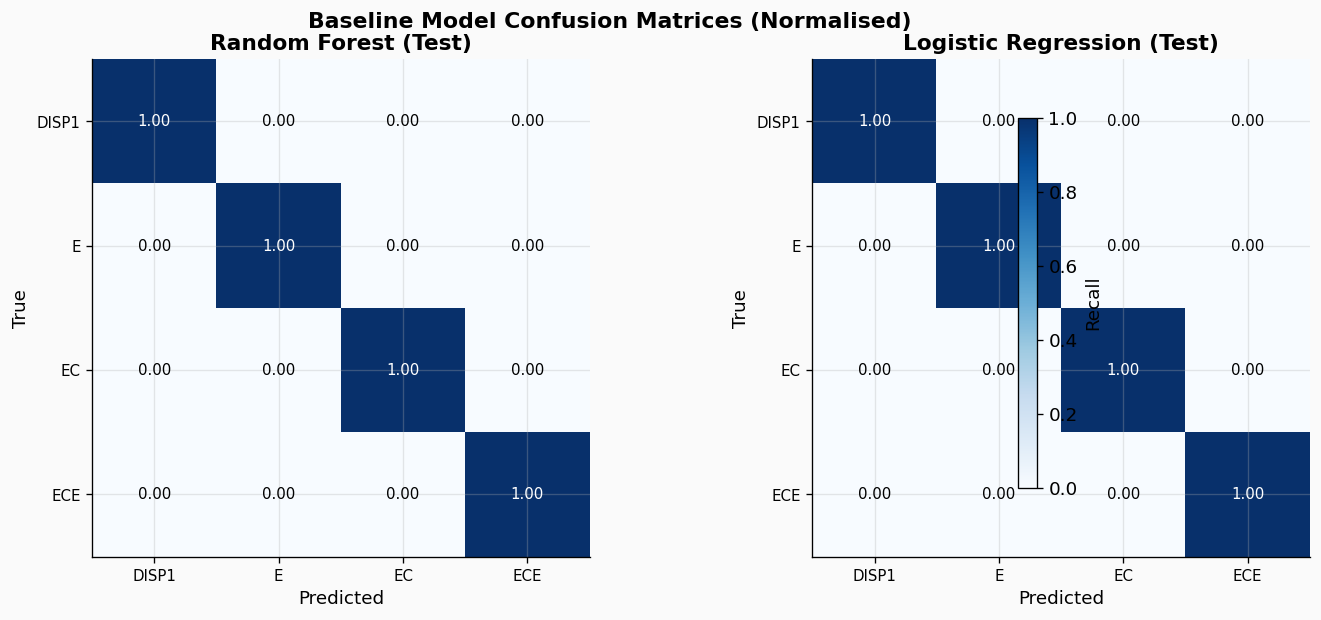

In [15]:
def plot_cm(y_true, y_pred, title, ax, normalize=True):
    """Plot a confusion matrix on a given axes."""
    n_cls = len(MECHANISMS)
    cm = sk_confusion_matrix(y_true, y_pred)
    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums = np.where(row_sums == 0, 1, row_sums)
        cm_disp = cm.astype(float) / row_sums
    else:
        cm_disp = cm.astype(float)

    im = ax.imshow(cm_disp, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(n_cls))
    ax.set_yticks(range(n_cls))
    ax.set_xticklabels(MECHANISMS, fontsize=9)
    ax.set_yticklabels(MECHANISMS, fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    thresh = 0.5
    for i in range(n_cls):
        for j in range(n_cls):
            val = cm_disp[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    color="white" if val > thresh else "black", fontsize=9)
    return im

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rf_preds = rf_clf.predict(X_test_feat)
lr_preds = lr_clf.predict(X_test_scaled)

plot_cm(y_test, rf_preds, "Random Forest (Test)", axes[0])
im = plot_cm(y_test, lr_preds, "Logistic Regression (Test)", axes[1])

fig.colorbar(im, ax=axes, shrink=0.8, label="Recall")
fig.suptitle("Baseline Model Confusion Matrices (Normalised)", fontweight="bold")
plt.tight_layout()
plt.show()

---

## 6. CNN Training — ResNet1D-18

### What the CNN learns (vs. the baselines)

The ResNet receives the raw **(18, 250) tensor** — 6 scan rates × 3 channels (`i_for`, `i_rev`, `v_n`) × 250 potential points. It never sees the 59-number summary.

The first `Conv1d` layer (kernel size 7) slides a window across the potential axis, detecting local patterns — a peak, a shoulder, a zero-crossing — in all 18 channels simultaneously. Each successive residual stage doubles the receptive field and channel width, so deeper layers combine local patterns into global shape descriptors. By the final `AdaptiveAvgPool1d`, the whole trace has been compressed into a **512-dim vector** capturing everything the network found discriminating.

Key advantage over the baselines: the CNN can learn **cross-scan-rate interactions implicitly** — e.g. *"the cathodic peak at SR5 is narrower than at SR0 by exactly this margin"* — without those relationships being pre-programmed as features. The hand-crafted features capture this only partially (via `std_peak_separation` etc.), and they assume the peak is always a clean maximum/minimum of the trace, which fails for multi-peak mechanisms like ECE.

| | Baselines (RF, LR) | ResNet1D-18 |
|---|---|---|
| Input | 59 hand-crafted scalars | Raw `(18, 250)` waveform |
| Feature design | Human (electrochemistry theory) | Learned from data |
| Cross-SR patterns | Partial (explicit ratios/slopes) | Full (learned jointly) |
| Multi-peak shapes | Fragile (single argmax) | Robust (convolutional) |
| Paper accuracy | 88–93% | **98.5%** (8-model ensemble) |

In [16]:
# If needed once per kernel:
# %pip install pyyaml wandb

from torch.utils.data import DataLoader
import copy
import os
from pathlib import Path
import wandb

import yaml

# -----------------------------
# 1) Load config + secrets
# -----------------------------
REPO_ROOT = Path.cwd().resolve().parent
CONFIG_PATH = REPO_ROOT / "configs" / "config.yaml"
SECRETS_PATH = REPO_ROOT / "configs" / ".secrets.yaml"

with open(CONFIG_PATH) as _f:
    full_cfg = yaml.safe_load(_f) or {}
if SECRETS_PATH.exists():
    with open(SECRETS_PATH) as _f:
        _secrets = yaml.safe_load(_f) or {}
    full_cfg.update(_secrets)
wb_cfg = full_cfg.get("wandb", {})
project_cfg = full_cfg.get("project", {})

print("W&B project:", wb_cfg.get("project"))
print("W&B entity :", wb_cfg.get("entity"))

# -----------------------------
# 2) Notebook toggles
# -----------------------------
WANDB_ENABLED = True
WANDB_MODE = "online"      # "online" or "offline"
RUN_SWEEP = False
SWEEP_COUNT = 8

# -----------------------------
# 3) CNN config (can override loaded config for notebook experiments)
# -----------------------------
CNN_CONFIG = {
    "training": {
        "batch_size": 64,              # ↑ from 32 — more stable gradients
        "epochs": 200,
        "lr": 1e-4,                    # lower starting LR for gentler warmup
        "max_lr": 1e-3,               # ↓ from 3e-3 — val loss was oscillating wildly
        "weight_decay": 1e-4,
        "label_smoothing": 0.1,        # keep — prevents overconfidence
        "grad_clip_norm": 1.0,         # keep — stabilizes training
        "early_stopping_patience": 30, # ↑ from 25 — give model more time with lower LR
        "mixup_alpha": 0.0,            # ↓ from 0.2 — DISABLED (too much reg with label smoothing)
    },
    "data": {
        "root": DATA_DIR,
        "num_workers": 0,
        "pin_memory": False,
        "augmentation": {
            "noise_sigma": 0.1,            # ↓ from 0.3 — was drowning the signal
            "baseline_drift": 0.05,        # keep
            "scale_jitter": 0.05,          # ↓ from 0.15 — gentler
            "time_shift_max": 5,           # ↓ from 10 — gentler
            "channel_dropout_prob": 0.05,  # ↓ from 0.1 — lighter
            "sr_shuffle_prob": 0.1,        # ↓ from 0.2 — lighter
        },
    },
}

train_dl, val_dl, test_dl = create_cv_dataloaders(CNN_CONFIG)

N_CLASSES = len(MECHANISMS)
model = get_model("resnet1d_18", in_channels=18, num_classes=N_CLASSES, zero_init_residual=True).to(DEVICE)

print()
print(f"Model: {model.__class__.__name__}")
print(f"Parameters: {model.count_parameters():,}")
print("Input shape: (batch, 18, 250)  [6 scan rates * 3 channels * 250 half-sweep points]")
print(f"Output shape: (batch, {N_CLASSES})")
print()
aug_cfg = CNN_CONFIG["data"]["augmentation"]
tcfg = CNN_CONFIG["training"]
print("Augmentations (train only):")
print(f"  Gaussian noise σ:       {aug_cfg['noise_sigma']}")
print(f"  Baseline drift:         ±{aug_cfg['baseline_drift']}")
print(f"  Scale jitter:           ±{aug_cfg['scale_jitter']:.0%}")
print(f"  Time shift:             ±{aug_cfg['time_shift_max']} pts")
print(f"  Channel dropout (p/SR): {aug_cfg['channel_dropout_prob']}")
print(f"  SR shuffle prob:        {aug_cfg['sr_shuffle_prob']}")
print(f"  Mixup alpha:            {tcfg['mixup_alpha']}")
print()
print("Training config:")
print(f"  Optimizer:              AdamW (wd={tcfg['weight_decay']})")
print(f"  Scheduler:              OneCycleLR (max_lr={tcfg['max_lr']})")
print(f"  Label smoothing:        {tcfg['label_smoothing']}")
print(f"  Gradient clipping:      max_norm={tcfg['grad_clip_norm']}")
print(f"  Early stopping:         patience={tcfg['early_stopping_patience']}")
print(f"  Epochs (max):           {tcfg['epochs']}")
print(f"  Zero-gamma BN:          True")

# -----------------------------
# 4) W&B init
# -----------------------------

# -----------------------------
# EDIT YOUR RUN NAME HERE:
WANDB_RUN_NAME = 'tuned-regularization-v2'
WANDB_RUN_NAME_FULL = project_cfg.get("experiment_id", f"cv_mech_resnet1d_{WANDB_RUN_NAME}")
# -----------------------------

wandb = None
if WANDB_ENABLED and not SKIP_TRAINING:
    try:
        import wandb as _wandb
        wandb = _wandb

        os.environ["WANDB_MODE"] = WANDB_MODE

        # Login from secrets (if present)
        wb_api_key = wb_cfg.get("api_key")
        if WANDB_MODE == "online" and wb_api_key:
            wandb.login(key=wb_api_key, relogin=True)

        if not RUN_SWEEP:
            wandb.init(
                project=wb_cfg.get("project"),
                entity=wb_cfg.get("entity"),
                config=full_cfg,  # resolved config + secrets merge
                name=WANDB_RUN_NAME_FULL,
                tags=wb_cfg.get("tags", ["notebook", "resnet1d", "cv-classification"]),
            )
            print(f"\nW&B run started in {WANDB_MODE} mode.")
        else:
            print(f"W&B sweep mode enabled ({WANDB_MODE}).")
    except ImportError:
        print("wandb is not installed. Install with: %pip install wandb")
        WANDB_ENABLED = False

W&B project: None
W&B entity : batesk052


INFO | CVDataset(train): 9600 samples, shape=(18, 250), noise=0.10, drift=0.05
INFO | CVDataset(val): 1200 samples, shape=(18, 250), noise=0.00, drift=0.00
INFO | CVDataset(test): 1200 samples, shape=(18, 250), noise=0.00, drift=0.00



Model: ResNet1D18
Parameters: 3,853,572
Input shape: (batch, 18, 250)  [6 scan rates * 3 channels * 250 half-sweep points]
Output shape: (batch, 4)

Augmentations (train only):
  Gaussian noise σ:       0.1
  Baseline drift:         ±0.05
  Scale jitter:           ±5%
  Time shift:             ±5 pts
  Channel dropout (p/SR): 0.05
  SR shuffle prob:        0.1
  Mixup alpha:            0.0

Training config:
  Optimizer:              AdamW (wd=0.0001)
  Scheduler:              OneCycleLR (max_lr=0.001)
  Label smoothing:        0.1
  Gradient clipping:      max_norm=1.0
  Early stopping:         patience=30
  Epochs (max):           200
  Zero-gamma BN:          True


### 6.0 Augmentation Examples

Visual comparison of clean vs. augmented CVs for each augmentation type.
Each column shows the effect of a single augmentation applied in isolation.

INFO | CVDataset(train): 9600 samples, shape=(18, 250), noise=0.00, drift=0.00
INFO | CVDataset(train): 9600 samples, shape=(18, 250), noise=0.10, drift=0.00
INFO | CVDataset(train): 9600 samples, shape=(18, 250), noise=0.00, drift=0.05
INFO | CVDataset(train): 9600 samples, shape=(18, 250), noise=0.00, drift=0.00
INFO | CVDataset(train): 9600 samples, shape=(18, 250), noise=0.00, drift=0.00
INFO | CVDataset(train): 9600 samples, shape=(18, 250), noise=0.00, drift=0.00
INFO | CVDataset(train): 9600 samples, shape=(18, 250), noise=0.00, drift=0.00


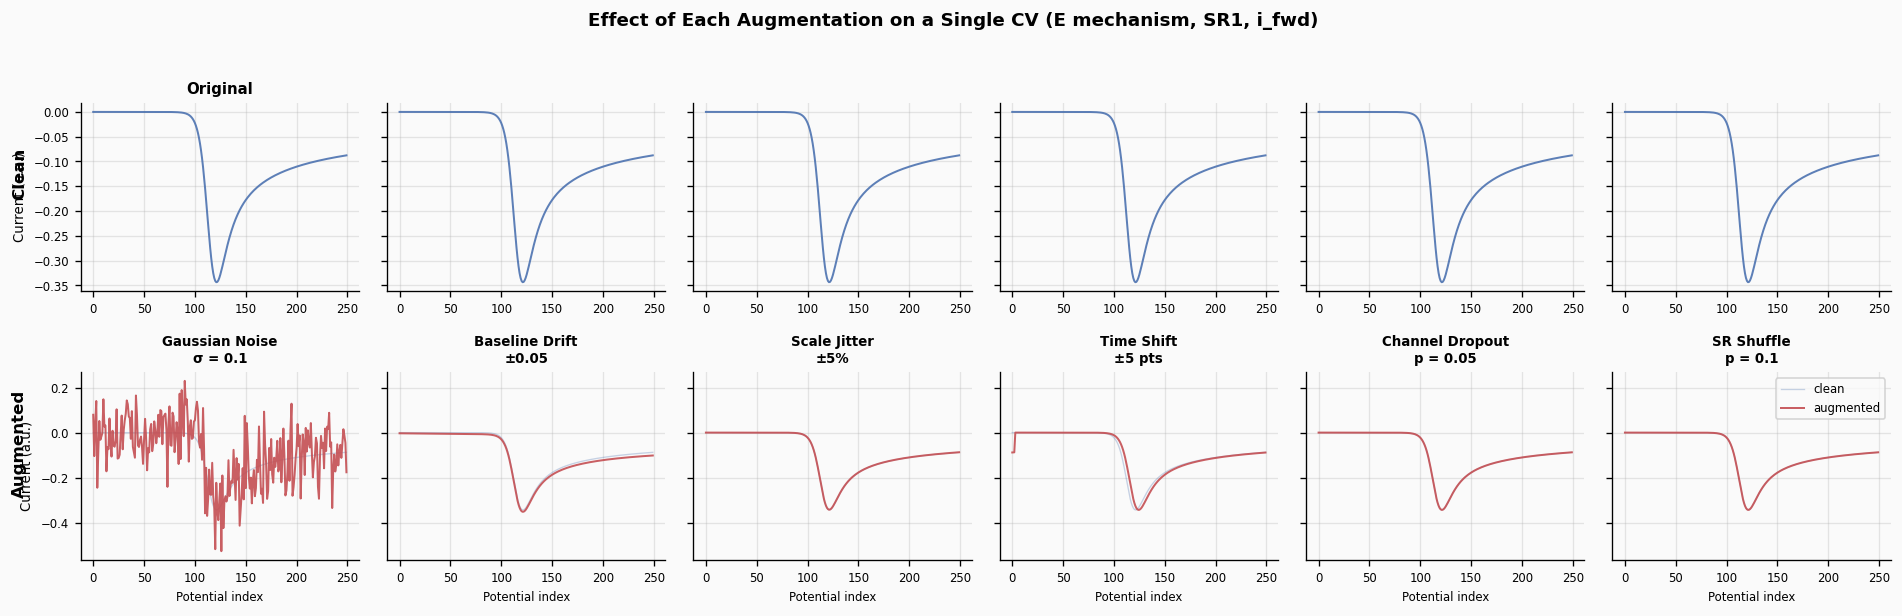

Saved to Report/figures/augmentation_examples.png


In [17]:
# --- Augmentation visualisation: clean vs. each augmentation in isolation ---
from src.data.cv_dataset import CVDataset

# Load a clean dataset (no augmentations) and pick one sample per mechanism
clean_ds = CVDataset(DATA_DIR, split="train")

# Find one example index per mechanism class
example_indices = {}
for i in range(len(clean_ds)):
    _, y = clean_ds[i]
    if y not in example_indices:
        example_indices[y] = i
    if len(example_indices) == 5:
        break

# Use mechanism 0 (E) for the augmentation demo — first scan rate, forward current channel
demo_idx = example_indices[0]
clean_x, clean_y = clean_ds[demo_idx]
clean_signal = clean_x[0].numpy()  # channel 0: i_fwd at SR1

# Define individual augmentations with their parameters
aug_specs = [
    ("Gaussian Noise\nσ = 0.1",   dict(noise_sigma=0.1)),
    ("Baseline Drift\n±0.05",     dict(baseline_drift=0.05)),
    ("Scale Jitter\n±5%",         dict(scale_jitter=0.05)),
    ("Time Shift\n±5 pts",        dict(time_shift_max=5)),
    ("Channel Dropout\np = 0.05", dict(channel_dropout_prob=0.05)),
    ("SR Shuffle\np = 0.1",       dict(sr_shuffle_prob=0.1)),
]

fig, axes = plt.subplots(2, len(aug_specs), figsize=(16, 5), sharey="row")

for col, (title, aug_kwargs) in enumerate(aug_specs):
    # Top row: clean signal (same in every column)
    axes[0, col].plot(clean_signal, color="#4C72B0", linewidth=1.2, alpha=0.9)
    axes[0, col].set_title("Original" if col == 0 else "", fontsize=9)
    axes[0, col].tick_params(labelsize=7)
    if col == 0:
        axes[0, col].set_ylabel("Current (a.u.)", fontsize=8)

    # Bottom row: augmented version
    # Create a dataset with just this one augmentation enabled
    aug_ds = CVDataset(DATA_DIR, split="train", **aug_kwargs)
    aug_x, _ = aug_ds[demo_idx]
    aug_signal = aug_x[0].numpy()

    axes[1, col].plot(clean_signal, color="#4C72B0", linewidth=0.8, alpha=0.3, label="clean")
    axes[1, col].plot(aug_signal, color="#C44E52", linewidth=1.2, alpha=0.9, label="augmented")
    axes[1, col].set_title(title, fontsize=8, fontweight="bold")
    axes[1, col].set_xlabel("Potential index", fontsize=7)
    axes[1, col].tick_params(labelsize=7)
    if col == 0:
        axes[1, col].set_ylabel("Current (a.u.)", fontsize=8)

# Add row labels
fig.text(0.01, 0.75, "Clean", fontsize=10, fontweight="bold", va="center", rotation=90)
fig.text(0.01, 0.30, "Augmented", fontsize=10, fontweight="bold", va="center", rotation=90)

axes[1, -1].legend(fontsize=7, loc="upper right")
fig.suptitle("Effect of Each Augmentation on a Single CV (E mechanism, SR1, i_fwd)",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../Report/figures/augmentation_examples.png", dpi=200, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Saved to Report/figures/augmentation_examples.png")

In [18]:
def mixup_data(x, y, alpha=0.2):
    """Apply mixup: blend pairs of samples and their labels.
    Returns mixed inputs, pairs of targets, and the mixing coefficient."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    return mixed_x, y, y[index], lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Compute loss for mixup: weighted combination of two targets."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


def _run_training_loop(run_overrides=None, log_to_wandb=False):
    cfg = copy.deepcopy(CNN_CONFIG)
    run_overrides = run_overrides or {}

    training_cfg = cfg.setdefault("training", {})
    for k in ["epochs", "batch_size", "lr", "max_lr", "weight_decay",
              "label_smoothing", "grad_clip_norm", "early_stopping_patience", "mixup_alpha"]:
        if k in run_overrides:
            training_cfg[k] = run_overrides[k]

    train_dl, val_dl, test_dl = create_cv_dataloaders(cfg)

    model = get_model("resnet1d_18", in_channels=18, num_classes=len(MECHANISMS), zero_init_residual=True).to(DEVICE)

    # --- Optimizer ---
    lr = float(training_cfg.get("lr", 1e-3))
    weight_decay = float(training_cfg.get("weight_decay", 1e-4))
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # --- Scheduler: OneCycleLR ---
    epochs = int(training_cfg.get("epochs", 200))
    max_lr = float(training_cfg.get("max_lr", 3e-3))
    steps_per_epoch = len(train_dl)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=max_lr,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        pct_start=0.1,       # 10% warmup
        anneal_strategy="cos",
        div_factor=max_lr / lr,        # start_lr = max_lr / div_factor = lr
        final_div_factor=1e4,          # end_lr = max_lr / (div_factor * final_div_factor)
    )

    # --- Loss with label smoothing ---
    label_smoothing = float(training_cfg.get("label_smoothing", 0.1))
    criterion = torch.nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    # --- Other hyperparams ---
    grad_clip_norm = float(training_cfg.get("grad_clip_norm", 1.0))
    patience = int(training_cfg.get("early_stopping_patience", 25))
    mixup_alpha = float(training_cfg.get("mixup_alpha", 0.2))
    use_amp = DEVICE.type == "cuda"
    scaler = torch.amp.GradScaler(enabled=use_amp)

    history = {"train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": [], "lr": []}
    best_val_acc = 0.0
    epochs_without_improvement = 0
    ckpt_path = os.path.join(REPO_ROOT, "checkpoints", "best_resnet1d.pt")
    os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

    header = f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}  {'LR':>8}"
    print(header)
    print("-" * len(header))

    for epoch in range(1, epochs + 1):
        # --- Train ---
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for x, y in train_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)

            # Mixup
            if mixup_alpha > 0:
                x_mixed, y_a, y_b, lam = mixup_data(x, y, mixup_alpha)
            else:
                x_mixed, y_a, y_b, lam = x, y, y, 1.0

            optimizer.zero_grad()
            with torch.amp.autocast(DEVICE.type, enabled=use_amp):
                out = model(x_mixed)
                loss = mixup_criterion(criterion, out, y_a, y_b, lam)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()  # OneCycleLR steps per batch, not per epoch

            total_loss += loss.item() * x.size(0)
            # For accuracy, compare against original (unmixed) labels
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)

        train_loss = total_loss / total
        train_acc = correct / total
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)

        # --- Validate ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        # Use a no-smoothing criterion for clean val loss
        val_criterion = torch.nn.CrossEntropyLoss()
        with torch.no_grad():
            for x, y in val_dl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                with torch.amp.autocast(DEVICE.type, enabled=use_amp):
                    out = model(x)
                    loss = val_criterion(out, y)
                val_loss += loss.item() * x.size(0)
                val_correct += (out.argmax(1) == y).sum().item()
                val_total += x.size(0)

        v_loss = val_loss / val_total
        v_acc = val_correct / val_total
        lr_now = optimizer.param_groups[0]["lr"]

        history["val_loss"].append(v_loss)
        history["val_accuracy"].append(v_acc)
        history["lr"].append(lr_now)

        if log_to_wandb and wandb is not None and wandb.run is not None:
            wandb.log(
                {
                    "train_loss": train_loss,
                    "train_accuracy": train_acc,
                    "val_loss": v_loss,
                    "val_accuracy": v_acc,
                    "lr": lr_now,
                    "epoch": epoch,
                },
                step=epoch,
            )

        # Save best checkpoint + early stopping
        best = v_acc > best_val_acc
        if best:
            best_val_acc = v_acc
            epochs_without_improvement = 0
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_accuracy": v_acc,
                "val_loss": v_loss,
            }, ckpt_path)
            import json as _jmod
            with open(ckpt_path.replace(".pt", "_history.json"), "w") as _hf:
                _jmod.dump(history, _hf)
        else:
            epochs_without_improvement += 1

        flag = " *" if best else ""
        print(f"{epoch:>6d}  {train_loss:>10.4f}  {train_acc:>8.2%}  {v_loss:>8.4f}  {v_acc:>6.2%}  {lr_now:>8.2e}{flag}")

        # Early stopping
        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping at epoch {epoch} (no improvement for {patience} epochs)")
            break

    best_epoch = int(np.argmax(history["val_accuracy"])) + 1
    print("-" * len(header))
    print(f"Best val accuracy: {best_val_acc:.2%}  (epoch {best_epoch})")
    print(f"Checkpoint saved to: {ckpt_path}")

    # Reload best checkpoint
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"Loaded best checkpoint from epoch {ckpt['epoch']}")

    if log_to_wandb and wandb is not None and wandb.run is not None:
        wandb.summary["best_val_accuracy"] = best_val_acc
        wandb.summary["best_epoch"] = best_epoch

    return history, model


history = None

if SKIP_TRAINING:
    # Load checkpoint instead of training
    _ckpt_path = RESUME_CHECKPOINT or os.path.join(REPO_ROOT, "checkpoints", "best_resnet1d.pt")
    assert os.path.exists(_ckpt_path), f"Checkpoint not found: {_ckpt_path}"
    _ckpt = torch.load(_ckpt_path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(_ckpt["model_state_dict"])
    model.eval()
    import json as _jmod
    _hist_path = _ckpt_path.replace(".pt", "_history.json")
    if os.path.exists(_hist_path):
        with open(_hist_path) as _hf:
            history = _jmod.load(_hf)
        n_ep = len(history["train_loss"])
        print(f"Loaded history ({n_ep} epochs) from: {_hist_path}")
    else:
        history = {"train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": [], "lr": []}
        print(f"No history file at {_hist_path} — training curves will be empty.")
    best_epoch = int(max(range(len(history["val_accuracy"])), key=lambda i: history["val_accuracy"][i], default=0)) + 1 if history["val_accuracy"] else None
    print(f"Checkpoint: epoch={_ckpt.get('epoch')}, val_acc={_ckpt.get('val_accuracy', 0):.4f}")

elif RUN_SWEEP:
    if not WANDB_ENABLED or wandb is None:
        raise RuntimeError("Sweep requested but W&B is not available. Enable WANDB and install wandb.")

    sweep_config = {
        "method": "bayes",
        "metric": {"name": "val_accuracy", "goal": "maximize"},
        "parameters": {
            "max_lr": {"distribution": "log_uniform_values", "min": 1e-4, "max": 1e-2},
            "weight_decay": {"distribution": "log_uniform_values", "min": 1e-6, "max": 1e-3},
            "label_smoothing": {"values": [0.0, 0.05, 0.1, 0.15]},
            "mixup_alpha": {"values": [0.0, 0.1, 0.2, 0.4]},
            "epochs": {"value": int(CNN_CONFIG["training"]["epochs"])},
            "batch_size": {"values": [16, 32, 64]},
        },
    }

    sweep_id = wandb.sweep(sweep_config, project=WANDB_PROJECT, entity=WANDB_ENTITY)
    print(f"Started sweep: {sweep_id}")

    def _sweep_train_fn():
        global history
        with wandb.init() as run:
            run_cfg = dict(wandb.config)
            hist, _ = _run_training_loop(run_overrides=run_cfg, log_to_wandb=True)
            history = hist

    wandb.agent(sweep_id, function=_sweep_train_fn, count=SWEEP_COUNT)
else:
    history, model = _run_training_loop(
        run_overrides=None,
        log_to_wandb=(WANDB_ENABLED and wandb is not None),
    )
    if WANDB_ENABLED and wandb is not None and wandb.run is not None:
        wandb.finish()

Loaded history (113 epochs) from: D:\repos\CMU.49.012-IDL-Main-Project\checkpoints\best_resnet1d_history.json
Checkpoint: epoch=83, val_acc=0.9967


### 6.1 Training Curves

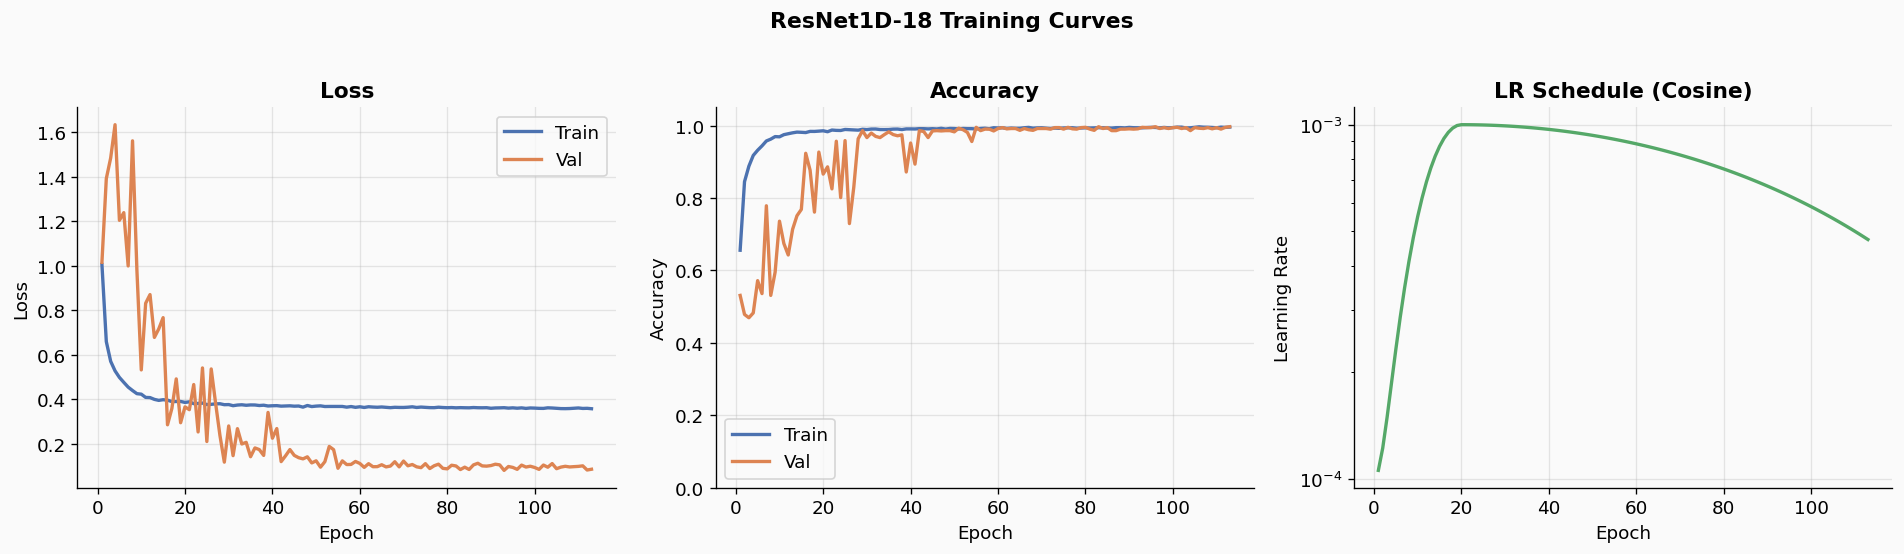

In [19]:
if not history or not history.get("train_loss"):
    print("No training history available (SKIP_TRAINING=True and no saved history). Skipping curves.")
else:
    epochs_range = range(1, len(history["train_loss"]) + 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    
    # Loss
    axes[0].plot(epochs_range, history["train_loss"], label="Train", color="#4C72B0", linewidth=2)
    axes[0].plot(epochs_range, history["val_loss"], label="Val", color="#DD8452", linewidth=2)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss")
    axes[0].legend()
    
    # Accuracy
    axes[1].plot(epochs_range, history["train_accuracy"], label="Train", color="#4C72B0", linewidth=2)
    axes[1].plot(epochs_range, history["val_accuracy"], label="Val", color="#DD8452", linewidth=2)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Accuracy")
    axes[1].legend()
    axes[1].set_ylim(0, 1.05)
    
    # Learning rate
    axes[2].plot(epochs_range, history["lr"], color="#55A868", linewidth=2)
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Learning Rate")
    axes[2].set_title("LR Schedule (Cosine)")
    axes[2].set_yscale("log")
    
    fig.suptitle("ResNet1D-18 Training Curves", fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

### 6.2 CNN Test Evaluation

In [20]:
def compute_metrics(y_true, y_pred, class_names=None):
    """Compute accuracy, per-class precision/recall/F1, and confusion matrix."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    acc = float(accuracy_score(y_true, y_pred))
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
    cm = sk_confusion_matrix(y_true, y_pred)
    if class_names is None:
        class_names = [str(l) for l in sorted(set(y_true.tolist()) | set(y_pred.tolist()))]
    per_class = [{"name": n, "precision": float(precision[i]), "recall": float(recall[i]),
                  "f1": float(f1[i]), "support": int(support[i])} for i, n in enumerate(class_names)]
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1,
            "confusion_matrix": cm, "class_names": class_names, "per_class": per_class}

# Evaluate on test set
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in test_dl:
        x = x.to(DEVICE)
        out = model(x)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(y.numpy())

cnn_preds = np.array(all_preds)
cnn_labels = np.array(all_labels)
cnn_test_acc = (cnn_preds == cnn_labels).mean()

# Per-class metrics
cnn_metrics = compute_metrics(cnn_labels, cnn_preds, class_names=MECHANISMS)

print(f"ResNet1D-18 Test Accuracy: {cnn_test_acc:.4f}\n")
print(f"{'Class':<8} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
print("-" * 50)
for entry in cnn_metrics["per_class"]:
    print(f"{entry['name']:<8} {entry['precision']:>10.3f} {entry['recall']:>10.3f} "
          f"{entry['f1']:>10.3f} {entry['support']:>10d}")

NameError: name 'confusion_matrix' is not defined

---

#### Sim-to-Real Results Log

| Method | Real Acc | Sim Acc | Notes |
|--------|----------|---------|-------|
| Baseline (no norm, 2026-03-17) | 22.73% (5/22) | 99.67% | Epoch 83 |
| + Per-channel normalization | 22.73% (5/22) | 100.0% | Epoch 13, faster convergence |
| + DANN | **31.82% (7/22)** | 100.0% | Best epoch 49/50, domain_weight=0.5 |
| + ADDA (lr=1e-4, 100ep) | **31.82% (7/22)** | 100.0% | Same accuracy as DANN, higher confidence |
| + ADDA (lr=5e-5, 100ep) | 31.82% (7/22) | 100.0% | Consistent across LR sweep |
| + ADDA (lr=1e-5, 50ep) | 31.82% (7/22) | 100.0% | Even small LR converges to same result |
| + Few-shot 1/class | 28.89% +/- 7.37% | - | Only n=1 possible (ECE=1 sample) |

All experiments: 2026-03-20

**Key patterns across all DA methods:**
- zenodo_sheng_2024_fig2a (EC, varying concentration): 4/4 correct in DANN and ADDA
- zenodo_sheng_2024_fig4c (EC, varying equivalents): 0/4 in all methods
- sandford_2019 (EC): 0/2 in all methods
- brown_2015 E samples: 2/3 correct in all methods
- Both DANN and ADDA plateau at exactly 31.82% -- suggests a hard ceiling with 22 samples
- Discriminator loss ~0.693 (=log2, random) in both methods -- too few real samples to learn

**Bottlenecks:** 22 real samples is insufficient for adversarial DA. Both DANN and ADDA
reach the same ceiling. The fig2a EC series transfers because it's closest to sim;
fig4c and sandford EC curves have fundamentally different shapes (likely iR drop,
capacitive background). Need either more real data or simulator improvements.

---

### 6.3 Sim-to-Real Transfer: CNN on Real Experimental CVs

In [ ]:
# Evaluate best CNN checkpoint on real experimental CV data
# Real data: 23 samples from digitized literature CVs (5 mechanisms)
# We filter to the 4 mechanisms the model was trained on (exclude CE)
# Uses Test-Time Augmentation (TTA) for more stable predictions.

from src.data.tta import tta_predict

# --- Load checkpoint (edit path to use a different one) ---
REAL_EVAL_CKPT = os.path.join(REPO_ROOT, "checkpoints", "best_resnet1d.pt")
assert os.path.exists(REAL_EVAL_CKPT), f"Checkpoint not found: {REAL_EVAL_CKPT}"
_ckpt = torch.load(REAL_EVAL_CKPT, map_location=DEVICE, weights_only=True)
model.load_state_dict(_ckpt["model_state_dict"])
model.eval()
print(f"Loaded checkpoint: {REAL_EVAL_CKPT}")
print(f"  epoch={_ckpt.get('epoch')}, val_acc={_ckpt.get('val_accuracy', 0):.4f}")

REAL_DATA_PATH = os.path.join(REPO_ROOT, "data", "real", "processed", "real_cvs.npz")
assert os.path.exists(REAL_DATA_PATH), f"Real data not found: {REAL_DATA_PATH}"

# Load raw real data
real_data = np.load(REAL_DATA_PATH, allow_pickle=True)
real_signals = real_data["signals"]        # (N, 6, 500)
real_labels_str = real_data["labels"]      # (N,) string labels
real_scan_rates = real_data["scan_rates"]  # (N, 6)
real_sources = real_data["sources"] if "sources" in real_data else None

print(f"Real dataset: {len(real_labels_str)} samples")
print(f"All labels:   {dict(Counter(real_labels_str.tolist()))}")

# Filter to the 4 trained mechanisms (drop CE)
mask = np.array([lbl in MECHANISMS for lbl in real_labels_str])
r_signals = real_signals[mask]
r_labels_str = real_labels_str[mask]
r_scan_rates = real_scan_rates[mask]
if real_sources is not None:
    real_sources = real_sources[mask]
dropped = (~mask).sum()
if dropped > 0:
    excluded = sorted(set(real_labels_str[~mask].tolist()))
    print(f"Excluded {dropped} samples with labels {excluded} (not in training set)")
print(f"Kept:         {len(r_labels_str)} samples — {dict(Counter(r_labels_str.tolist()))}")

# Preprocess: same channel layout as training (N, 6, 500) -> (N, 18, 250)
n, n_sr, length = r_signals.shape
mid = length // 2
real_tensor = np.empty((n, n_sr * 3, mid), dtype=np.float32)
for sr_i in range(n_sr):
    real_tensor[:, sr_i * 3,     :] = r_signals[:, sr_i, :mid]       # i_forward
    real_tensor[:, sr_i * 3 + 1, :] = r_signals[:, sr_i, mid:]       # i_reverse
    real_tensor[:, sr_i * 3 + 2, :] = r_scan_rates[:, sr_i:sr_i+1]   # scan rate

# Normalize using training set statistics (must match CVDataset normalization)
# Load a dummy training dataset to get channel_mean / channel_std
_norm_ds = CVDataset(
    os.path.join(REPO_ROOT, "data", "simulated"),
    split="train",
)
ch_mean = _norm_ds.channel_mean[np.newaxis, :, np.newaxis]  # (1, C, 1)
ch_std = _norm_ds.channel_std[np.newaxis, :, np.newaxis]    # (1, C, 1)
real_tensor = (real_tensor - ch_mean) / ch_std
print(f"Applied training-set normalization (z-score current, min-max scan rate)")

real_X = torch.from_numpy(real_tensor).to(DEVICE)
real_y = np.array([MECHANISM_TO_IDX[lbl] for lbl in r_labels_str])

# --- Single-pass inference (baseline) ---
model.eval()
with torch.no_grad():
    logits = model(real_X)
    single_preds = logits.argmax(dim=1).cpu().numpy()
    single_probs = torch.softmax(logits, dim=1).cpu().numpy()

single_acc = (single_preds == real_y).mean()

# --- TTA inference (n_aug augmented copies + 1 clean) ---
N_TTA = 20
tta_probs, tta_preds = tta_predict(
    model, real_X, n_aug=N_TTA, device=DEVICE,
)
tta_acc = (tta_preds == real_y).mean()
tta_metrics = compute_metrics(real_y, tta_preds, class_names=MECHANISMS)

print(f"\n{'='*60}")
print(f"Real Data Accuracy (single pass): {single_acc:.2%}  ({(single_preds == real_y).sum()}/{len(real_y)})")
print(f"Real Data Accuracy (TTA, n={N_TTA}):   {tta_acc:.2%}  ({(tta_preds == real_y).sum()}/{len(real_y)})")
print(f"{'='*60}")
print(f"\n{'Class':<8} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>8}")
print("-" * 48)
for entry in tta_metrics['per_class']:
    print(f"{entry['name']:<8} {entry['precision']:>10.4f} {entry['recall']:>10.4f} "
          f"{entry['f1']:>10.4f} {entry['support']:>8d}")

# Sim-to-real gap
print(f"\nSim-to-real gap: {cnn_test_acc:.2%} (sim) → {tta_acc:.2%} (real) = "
      f"Δ {cnn_test_acc - tta_acc:+.2%}")

# Per-sample breakdown (TTA vs single-pass)
print(f"\n{'#':<4} {'True':<8} {'Pred(1x)':<10} {'Pred(TTA)':<10} {'Conf(TTA)':>10}  Source")
print("-" * 72)
for i in range(len(real_y)):
    true_name = MECHANISMS[real_y[i]]
    pred_1x = MECHANISMS[single_preds[i]]
    pred_tta = MECHANISMS[tta_preds[i]]
    conf = tta_probs[i].max()
    marker = '' if single_preds[i] == tta_preds[i] else ' << FLIPPED'
    source = real_sources[i] if real_sources is not None else ''
    print(f"{i:<4} {true_name:<8} {pred_1x:<10} {pred_tta:<10} {conf:>10.4f}  {source}{marker}")

In [ ]:
# --- Simulated vs Real EC Curves: Side-by-Side Comparison ---
import glob

# Load simulated data from npz file in DATA_DIR
sim_npz_path = glob.glob(os.path.join(DATA_DIR, "*.npz"))[0]
sim_data = np.load(sim_npz_path)
sim_signals = sim_data["signals"]      # (N, 6, 500)
sim_labels = sim_data["labels"]         # (N,) string labels

# Filter to EC mechanism only
sim_ec_mask = sim_labels == "EC"
sim_ec_signals = sim_signals[sim_ec_mask]

real_ec_mask = r_labels_str == "EC"
real_ec_signals = r_signals[real_ec_mask]

# Pick 3 random examples from each
rng = np.random.default_rng(42)
sim_idx = rng.choice(len(sim_ec_signals), size=3, replace=False)
real_idx = rng.choice(len(real_ec_signals), size=min(3, len(real_ec_signals)), replace=False)

scan_rate_colors = plt.cm.viridis(np.linspace(0.1, 0.9, 6))
scan_rate_labels = [f"SR {i+1}" for i in range(6)]

fig, axes = plt.subplots(3, 2, figsize=(14, 10), constrained_layout=True)
fig.suptitle("Simulated vs Real EC Curves — Distribution Comparison",
             fontsize=14, fontweight="bold")

for row in range(3):
    # Left column: simulated
    ax_sim = axes[row, 0]
    for ch in range(6):
        ax_sim.plot(sim_ec_signals[sim_idx[row], ch, :],
                    color=scan_rate_colors[ch], label=scan_rate_labels[ch],
                    linewidth=0.9, alpha=0.85)
    ax_sim.set_ylabel("Current (a.u.)")
    if row == 0:
        ax_sim.set_title("Simulated EC", fontsize=12)
    if row == 2:
        ax_sim.set_xlabel("Potential index")
    ax_sim.tick_params(labelsize=8)

    # Right column: real
    ax_real = axes[row, 1]
    ri = real_idx[row % len(real_idx)]
    for ch in range(6):
        ax_real.plot(real_ec_signals[ri, ch, :],
                     color=scan_rate_colors[ch], label=scan_rate_labels[ch],
                     linewidth=0.9, alpha=0.85)
    if row == 0:
        ax_real.set_title("Real EC", fontsize=12)
    if row == 2:
        ax_real.set_xlabel("Potential index")
    ax_real.tick_params(labelsize=8)

# Add shared legend
handles, lbls = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, lbls, loc="center right", fontsize=8,
           title="Scan Rate", title_fontsize=9)
plt.subplots_adjust(right=0.88)

plt.savefig(os.path.join(REPO_ROOT, "figures", "sim_vs_real_ec.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Plotted {len(sim_idx)} simulated and {len(real_idx)} real EC examples.")

---

## 7. Model Comparison

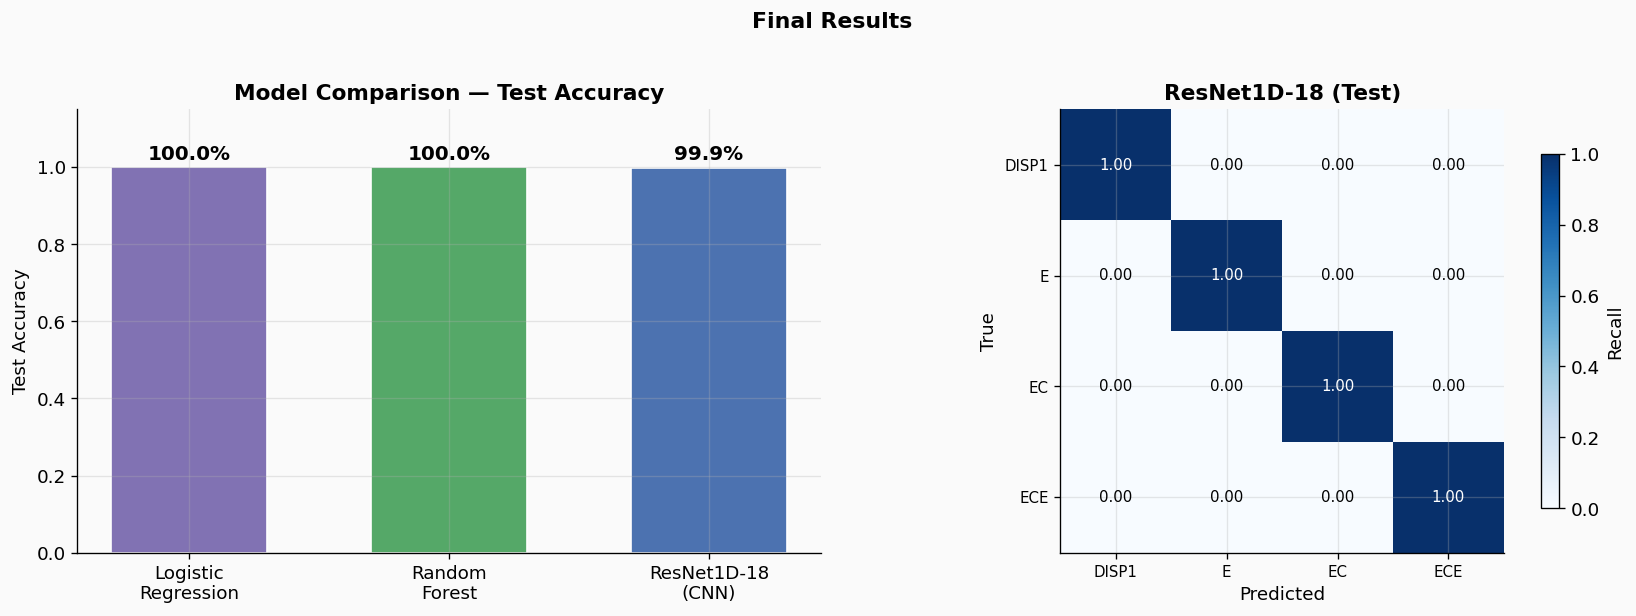

In [ ]:
# --- Accuracy comparison bar chart ---
models = ["Logistic\nRegression", "Random\nForest", "ResNet1D-18\n(CNN)"]
test_accs = [lr_test_acc, rf_test_acc, cnn_test_acc]
bar_colors = ["#8172B3", "#55A868", "#4C72B0"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(models, test_accs, color=bar_colors, edgecolor="white", width=0.6)
for bar, acc in zip(bars, test_accs):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{acc:.1%}", ha="center", va="bottom", fontweight="bold", fontsize=12)
axes[0].set_ylabel("Test Accuracy")
axes[0].set_title("Model Comparison — Test Accuracy")
axes[0].set_ylim(0, 1.15)

# CNN confusion matrix
im = plot_cm(cnn_labels, cnn_preds, "ResNet1D-18 (Test)", axes[1])
fig.colorbar(im, ax=axes[1], shrink=0.8, label="Recall")

fig.suptitle("Final Results", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 7.1 Per-Class F1 Comparison

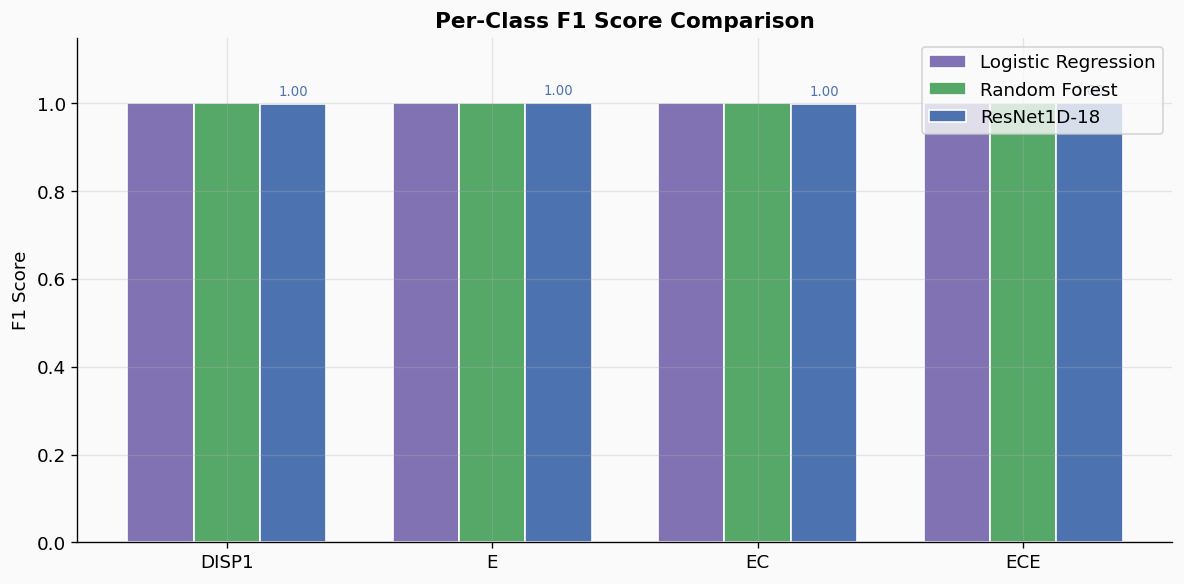

In [ ]:
# Compute per-class F1 for all models
rf_metrics = compute_metrics(y_test, rf_preds, class_names=MECHANISMS)
lr_metrics = compute_metrics(y_test, lr_preds, class_names=MECHANISMS)

x_pos = np.arange(len(MECHANISMS))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

lr_f1 = [e["f1"] for e in lr_metrics["per_class"]]
rf_f1 = [e["f1"] for e in rf_metrics["per_class"]]
cnn_f1 = [e["f1"] for e in cnn_metrics["per_class"]]

ax.bar(x_pos - width, lr_f1, width, label="Logistic Regression", color="#8172B3", edgecolor="white")
ax.bar(x_pos, rf_f1, width, label="Random Forest", color="#55A868", edgecolor="white")
ax.bar(x_pos + width, cnn_f1, width, label="ResNet1D-18", color="#4C72B0", edgecolor="white")

ax.set_xticks(x_pos)
ax.set_xticklabels(MECHANISMS, fontsize=11)
ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1 Score Comparison")
ax.set_ylim(0, 1.15)
ax.legend(loc="upper right")

# Annotate CNN bars
for i, f1 in enumerate(cnn_f1):
    ax.text(i + width, f1 + 0.02, f"{f1:.2f}", ha="center", fontsize=8, color="#4C72B0")

plt.tight_layout()
plt.show()

---

## Summary

| Model | Features | Test Accuracy | Notes |
|-------|----------|:---:|-------|
| Logistic Regression | 59 hand-crafted | — | Linear baseline |
| Random Forest | 59 hand-crafted | — | Non-linear baseline |
| **ResNet1D-18** | **Raw signal (6×500)** | **—** | **CNN (paper approach)** |

*Actual values printed above. Dataset: 12 000 samples, 4 mechanisms (DISP1, E, EC, ECE), 3 000 per class.*

### Augmentations (train only)
| Augmentation | Parameter | Purpose |
|---|---|---|
| Gaussian noise | σ = 0.3 | Simulate measurement noise |
| Baseline drift | ±0.05 | Simulate electrode fouling / reference drift |
| Scale jitter | ±15% | Simulate concentration / electrode area variation |
| Time shift | ±10 pts | Simulate reference electrode potential offset |
| Channel dropout | p = 0.1/SR | Force robustness to missing scan rates |
| SR shuffle | p = 0.2 | Prevent reliance on scan-rate ordering |
| **Mixup** | α = 0.2 | Interpolate training samples for smoother decision boundaries |

### Training Techniques
| Technique | Setting | Purpose |
|---|---|---|
| Label smoothing | 0.1 | Prevent overconfident predictions, improve calibration |
| OneCycleLR | max_lr=3e-3, 10% warmup | Aggressive warmup + cosine annealing for faster convergence |
| Gradient clipping | max_norm=1.0 | Stabilize training, prevent exploding gradients |
| Early stopping | patience=25 | Stop training when validation plateaus |
| Zero-gamma BN | bn2.weight=0 at init | Residual blocks start as identity → smoother optimization |
| GradScaler (AMP) | auto | Mixed precision for faster GPU training |

### Next Steps
- Add **CE mechanism** data to restore the 5-class setup from the paper
- Add **noise robustness** evaluation (vary sigma at test time)
- Implement **domain adaptation** for sim-to-real transfer using `data/real/processed/real_cvs.npz`
- **Ensemble** 8 models for voting (paper achieves 98.5%)
- Try **SGD+momentum** as an alternative optimizer (often generalises better)
- Try **Focal loss** if class confusion persists (EC vs ECE)

---

## 8. Paper Visualizations

Production-ready figures exported to `Report/figures/`.  
Run after **Section 6** (CNN training) is complete — requires `model`, `test_loader`, `device`, `MECHANISMS`, `MECH_COLORS`, `potential`.

### 8.0 Setup

In [ ]:
import os
from sklearn.manifold import TSNE
import matplotlib.cm as cm
import matplotlib.colors as mcolors

FIG_DIR = os.path.join("..", "Report", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, format="svg", bbox_inches="tight", dpi=150)
    print(f"Saved: {path}")

# ── Load best checkpoint ───────────────────────────────────────────────────────
# Change this path to switch checkpoints. Everything in Section 8 uses viz_model.
CKPT_PATH = os.path.join("..", "checkpoints", "best_resnet1d.pt")

EXPECTED_IN_CHANNELS = 18          # 6 scan rates × 3 channels
EXPECTED_NUM_CLASSES = len(MECHANISMS)  # 4

print(f"Loading: {CKPT_PATH}")
assert os.path.exists(CKPT_PATH), f"Checkpoint not found: {CKPT_PATH}"

ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
assert isinstance(ckpt, dict), "Unexpected checkpoint format (expected dict)"
assert "model_state_dict" in ckpt, f"No model_state_dict in checkpoint. Keys: {list(ckpt.keys())}"

sd = ckpt["model_state_dict"]

# ── Architecture validation ────────────────────────────────────────────────────
actual_in_ch   = sd["conv1.weight"].shape[1]   # (out, in, kernel)
actual_classes = sd["fc.weight"].shape[0]       # (num_classes, 512)

assert actual_in_ch == EXPECTED_IN_CHANNELS, (
    f"in_channels mismatch: checkpoint has {actual_in_ch}, expected {EXPECTED_IN_CHANNELS}"
)
assert actual_classes == EXPECTED_NUM_CLASSES, (
    f"num_classes mismatch: checkpoint has {actual_classes}, expected {EXPECTED_NUM_CLASSES} {MECHANISMS}"
)

# ── Build & load ───────────────────────────────────────────────────────────────
viz_model = get_model(
    "resnet1d_18",
    in_channels=EXPECTED_IN_CHANNELS,
    num_classes=EXPECTED_NUM_CLASSES,
    zero_init_residual=True,
).to(DEVICE)
viz_model.load_state_dict(sd)
viz_model.eval()

# ── Smoke test: dummy forward pass ────────────────────────────────────────────
with torch.no_grad():
    _dummy = torch.zeros(2, EXPECTED_IN_CHANNELS, 250, device=DEVICE)
    _out   = viz_model(_dummy)
assert _out.shape == (2, EXPECTED_NUM_CLASSES), f"Unexpected output shape: {_out.shape}"

# ── Summary ────────────────────────────────────────────────────────────────────
print(f"  Saved at epoch : {ckpt.get('epoch', 'unknown')}")
print(f"  Val accuracy   : {ckpt.get('val_accuracy', 'unknown'):.4f}")
print(f"  Val loss       : {ckpt.get('val_loss', 'unknown'):.4f}")
print(f"  Architecture   : in_channels={actual_in_ch}  num_classes={actual_classes}  ✓")
print(f"  Forward pass   : output shape {list(_out.shape)}  ✓")
print(f"  Ready          : viz_model loaded on {DEVICE}")

# test_loader alias (Section 8 cells use test_loader; training cells use test_dl)
test_loader = test_dl


### 8.1 t-SNE — Feature Space Colored by Mechanism Class

Extract 512-dim backbone features via a forward hook on `avgpool`, then
project to 2-D with t-SNE. Tight, separated clusters confirm the model has
learned a clean mechanism-discriminative representation.

In [ ]:
# ── Feature extraction via avgpool hook ──────────────────────────────────
_hook = {}

def _avgpool_hook(module, inp, out):
    _hook["feats"] = out.squeeze(-1).detach().cpu()  # (B, 512)

handle = viz_model.avgpool.register_forward_hook(_avgpool_hook)

viz_model.eval()
feats_list, labels_tsne = [], []
with torch.no_grad():
    for x, y in test_loader:
        _ = viz_model(x.to(device))
        feats_list.append(_hook["feats"])
        labels_tsne.append(y)

handle.remove()
features_arr = torch.cat(feats_list).numpy()   # (N, 512)
labels_arr   = torch.cat(labels_tsne).numpy()  # (N,)

# ── t-SNE ─────────────────────────────────────────────────────────────────
print("Running t-SNE on", features_arr.shape[0], "test samples...")
tsne = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=42)
emb  = tsne.fit_transform(features_arr)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
for i, mech in enumerate(MECHANISMS):
    mask = labels_arr == i
    ax.scatter(emb[mask, 0], emb[mask, 1],
               c=MECH_COLORS[mech], label=mech,
               alpha=0.65, s=18, linewidths=0)

ax.legend(title="Mechanism", framealpha=0.9, fontsize=9)
ax.set_title("t-SNE: ResNet1D Feature Space (test set, colored by class)",
             fontweight="bold")
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
save_fig("tsne_by_class.svg")
plt.show()


### 8.2 Grad-CAM — Which Regions of the CV Does the ResNet Attend To?

Grad-CAM backpropagates the predicted-class score through `layer4` (last
residual stage, spatial dim ≈ 8) to produce a saliency map over the 250
potential points. Red regions = high model attention. Expected to align with
the oxidation/reduction peaks that electrochemists use for manual identification.

> **Why it matters:** No published CV classification paper shows this. It directly
> validates the model is attending to chemically meaningful signal features.

In [ ]:
# ── Grad-CAM on layer4 ───────────────────────────────────────────────────
_gcam = {}

def _fwd_hook(module, inp, out):
    _gcam["activations"] = out                      # (B, 512, L')

def _bwd_hook(module, grad_in, grad_out):
    _gcam["gradients"]   = grad_out[0]              # (B, 512, L')

fwd_h = viz_model.layer4.register_forward_hook(_fwd_hook)
bwd_h = viz_model.layer4.register_full_backward_hook(_bwd_hook)

# Pick first test sample of each mechanism
sample_tensors = {}
viz_model.eval()
for x, y in test_loader:
    for i in range(len(y)):
        lbl = y[i].item()
        if lbl not in sample_tensors:
            sample_tensors[lbl] = x[i:i+1]
    if len(sample_tensors) == len(MECHANISMS):
        break

fig, axes = plt.subplots(len(MECHANISMS), 1,
                         figsize=(12, 3.2 * len(MECHANISMS)))
axes = axes if len(MECHANISMS) > 1 else [axes]

for mech_idx, mech in enumerate(MECHANISMS):
    ax = axes[mech_idx]
    x_in = sample_tensors[mech_idx].to(device)

    viz_model.zero_grad()
    logits = viz_model(x_in)
    logits[0, mech_idx].backward()   # grad w.r.t. predicted class

    # Grad-CAM: pool gradients over spatial dim → channel weights
    acts  = _gcam["activations"].detach()        # (1, 512, L')
    grads = _gcam["gradients"].detach()          # (1, 512, L')
    weights = grads.mean(dim=-1, keepdim=True)  # (1, 512, 1)
    cam = (weights * acts).sum(dim=1).squeeze()  # (L',)
    cam = torch.relu(cam)

    # Upsample to input length 250
    cam_up = torch.nn.functional.interpolate(
        cam.unsqueeze(0).unsqueeze(0),
        size=250, mode="linear", align_corners=False
    ).squeeze().cpu().numpy()
    cam_up = (cam_up - cam_up.min()) / (cam_up.max() - cam_up.min() + 1e-8)

    # CV trace: forward half-sweep, first scan rate, channel 0 (i_fwd)
    trace = x_in[0, 0, :].detach().cpu().numpy()

    ax.plot(potential[:125], trace[:125],
            color=MECH_COLORS[mech], linewidth=1.8, zorder=3)
    ax.plot(potential[125:], trace[125:],
            color=MECH_COLORS[mech], linewidth=1.8,
            linestyle="--", zorder=3)

    # Overlay Grad-CAM as coloured background spans
    for j in range(249):
        if cam_up[j] > 0.05:   # skip near-zero regions for speed
            ax.axvspan(potential[j], potential[j+1],
                       alpha=0.4 * cam_up[j], color="#E74C3C", linewidth=0)

    ax.set_title(f"{mech} — Grad-CAM saliency",
                 fontsize=10, color=MECH_COLORS[mech])
    ax.set_ylabel("i (norm.)")
    if mech_idx == len(MECHANISMS) - 1:
        ax.set_xlabel("E (V)")

fwd_h.remove(); bwd_h.remove()
fig.suptitle("Grad-CAM: ResNet1D Attention over CV Signal"
             " (red = high saliency)", fontweight="bold")
plt.tight_layout()
save_fig("gradcam.svg")
plt.show()


### 8.3 Failure Case Analysis — Misclassified CVs

For each off-diagonal confusion pair, plot up to 2 actual CV traces that
were misclassified. Satisfies the rubric *'≥1 failure mode identified'* requirement.

In [ ]:
# ── Collect test predictions ─────────────────────────────────────────────
viz_model.eval()
mc_preds, mc_true, mc_sigs = [], [], []

with torch.no_grad():
    for x, y in test_loader:
        mc_preds.append(viz_model(x.to(device)).argmax(1).cpu())
        mc_true.append(y)
        mc_sigs.append(x)

mc_preds = torch.cat(mc_preds).numpy()
mc_true  = torch.cat(mc_true).numpy()
mc_sigs  = torch.cat(mc_sigs).numpy()

from collections import defaultdict
mistakes = defaultdict(list)
for i in np.where(mc_preds != mc_true)[0]:
    mistakes[(mc_true[i], mc_preds[i])].append(i)

if not mistakes:
    print("No misclassifications on test set (100% accuracy).")
else:
    MAX_PER_PAIR = 2
    pairs = sorted(mistakes.items())
    fig, axes = plt.subplots(len(pairs), MAX_PER_PAIR,
                             figsize=(10, 3.5 * len(pairs)), squeeze=False)

    for row, ((tc, pc), idxs) in enumerate(pairs):
        for col in range(MAX_PER_PAIR):
            ax = axes[row][col]
            if col < len(idxs):
                sig = mc_sigs[idxs[col], 0, :]
                ax.plot(potential[:125], sig[:125],
                        color=MECH_COLORS[MECHANISMS[tc]], linewidth=1.5)
                ax.plot(potential[125:], sig[125:],
                        color=MECH_COLORS[MECHANISMS[tc]], linewidth=1.5,
                        linestyle="--")
                ax.set_title(
                    f"True: {MECHANISMS[tc]}  →  Pred: {MECHANISMS[pc]}",
                    fontsize=9, color="#C0392B")
                ax.set_xlabel("E (V)"); ax.set_ylabel("i (norm.)")
            else:
                ax.set_visible(False)

    fig.suptitle("Failure Cases: Misclassified CV Traces", fontweight="bold")
    plt.tight_layout()
    save_fig("failure_cases.svg")
    plt.show()
    print(f"{(mc_preds != mc_true).sum()} misclassifications across {len(pairs)} pairs.")


### 8.4 Scan-Rate Ablation — How Many Scan Rates Are Needed?

Zero out scan rates beyond *n* and measure test accuracy for n = 1 … 6.
Reproduces Hoar et al. (2022) Fig. 2E on our dataset.
Input format: `(B, 18, 250)` — scan rate *i* occupies channels `[i*3, i*3+2]`.

In [ ]:
# ── Scan-rate ablation ────────────────────────────────────────────────────
SR_VALUES = [0.10, 0.16, 0.25, 0.40, 0.63, 1.00]  # V/s
sr_accs = []

viz_model.eval()
for n_sr in range(1, 7):
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x_m = x.clone()
            x_m[:, n_sr * 3:, :] = 0.0          # zero out SRs beyond n_sr
            preds = viz_model(x_m.to(device)).argmax(1).cpu()
            correct += (preds == y).sum().item()
            total   += len(y)
    acc = correct / total
    sr_accs.append(acc)
    print(f"  n_sr={n_sr}  acc={acc:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 7), sr_accs, marker='o', color='#4C72B0',
        linewidth=2, markersize=7)
ax.set_xlabel("Number of scan rates used (1 = slowest only)")
ax.set_ylabel("Test Accuracy")
ax.set_xticks(range(1, 7))
ax.set_xticklabels([f'n={i}\n({SR_VALUES[i-1]:.2f} V/s)' for i in range(1, 7)])
ax.set_ylim(0, 1.05)
ax.axhline(sr_accs[-1], color='grey', linestyle='--', linewidth=1,
           label=f'Full viz_model ({sr_accs[-1]:.3f})')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_title("Scan-Rate Ablation: Accuracy vs. Number of Scan Rates",
             fontweight="bold")
plt.tight_layout()
save_fig('scanrate_ablation.svg')
plt.show()


### 8.5 t-SNE — Feature Space Colored by Domain (sim vs. real)

> **TODO — Final submission.** Run after DANN is implemented and real CV
> data (`data/real/processed/real_cvs.npz`) is available.
>
> **Three panels to produce:**
> 1. Before adaptation, colored by **class** → already done in §8.1
> 2. Before adaptation, colored by **domain** (sim=blue / real=orange) → shows the gap
> 3. After DANN, colored by **domain** → sim/real merge = *money shot* for the paper
>
> The before → after comparison is the primary result figure for the final paper.
> See `src/models/dann.py` (planned) for the `DANNResNet1D18` model.

In [ ]:
# TODO: uncomment and run after DANN + real data are ready
#
# from src.models.dann import DANNResNet1D18
#
# real_dataset = ...  # load data/real/processed/real_cvs.npz
# real_loader  = DataLoader(real_dataset, batch_size=64, shuffle=False)
#
# def extract_features(m, loader):
#     _h = {}
#     def hook(mod, inp, out): _h['f'] = out.squeeze(-1).detach().cpu()
#     handle = m.avgpool.register_forward_hook(hook)
#     feats, labs = [], []
#     with torch.no_grad():
#         for x, y in loader:
#             _ = m(x.to(device)); feats.append(_h['f']); labs.append(y)
#     handle.remove()
#     return torch.cat(feats).numpy(), torch.cat(labs).numpy()
#
# sim_feats,  sim_labs  = extract_features(viz_model, test_loader)
# real_feats, real_labs = extract_features(viz_model, real_loader)
#
# all_feats   = np.concatenate([sim_feats, real_feats])
# domain_labs = np.array([0]*len(sim_feats) + [1]*len(real_feats))
#
# emb = TSNE(n_components=2, perplexity=40, random_state=42).fit_transform(all_feats)
#
# fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# for d, (lbl, col) in enumerate([('Sim', '#4C72B0'), ('Real', '#DD8452')]):
#     mask = domain_labs == d
#     axes[0].scatter(emb[mask,0], emb[mask,1], c=col, label=lbl, alpha=0.5, s=15)
# axes[0].set_title('Before DANN — by domain'); axes[0].legend()
# axes[1].set_title('After DANN — by domain  (replace features with DANN viz_model output)')
# fig.suptitle('t-SNE: Sim-to-Real Domain Alignment', fontweight='bold')
# plt.tight_layout(); save_fig('tsne_by_domain.svg'); plt.show()
print('TODO: implement after DANN training and real data are ready.')
